In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Heiti TC' 
matplotlib.rcParams['axes.unicode_minus'] = False
# [选择 read_csv 不传 parse_dates]
# 先以原始类型读入，在模块一 1.2 再显式转换，使每步意图明确。
# 若 read_csv 内部静默解析失败会产生 NaT，不如让体检步骤主动抛异常。
df      = pd.read_csv("数据.csv")
df_raw  = df.copy()   # 原始副本，只用于 1.1 字段观察，后续不再修改

# [集中定义核心字段]
# 三字段直接决定因子可计算性，集中定义后各模块统一引用，改动只需改一处。
# buy_value + sell_value → 决定 a 能否当天计算
# pct_rate              → 决定 rolling 窗口内低收益日能否识别
CORE_COLS = ['buy_value', 'sell_value', 'pct_rate']

print("读取完成。")
print(f"  df.shape   = {df.shape}")
print(f"  CORE_COLS  = {CORE_COLS}")

读取完成。
  df.shape   = (7100847, 7)
  CORE_COLS  = ['buy_value', 'sell_value', 'pct_rate']


In [133]:
# ===========================================================
# 【模块一】基础数据体检
# ===========================================================
print("=" * 60)
print("【模块一】基础数据体检")
print("=" * 60)

# ── 1.1 df_raw 字段概览 ─────────────────────────────────────────────────────
# [选择 dtypes 逐行打印而非 df.info()]
# dtypes 返回 Series，可迭代格式化，不附带"memory usage"等干扰信息。
# df.info() 返回 None（副作用打印），无法程序化判断字段类型是否符合预期。
# 先看 df_raw（未做任何转换的原始状态），再对 df 做转换，保持体检逻辑清晰。
# 常见异常：buy_value 读成 object（CSV 含逗号/引号），date 读成 object（格式不标准）。
print("\n[1.1] df_raw 字段和类型（原始读入，未做任何转换）")
print(f"  columns : {list(df_raw.columns)}")
print("  dtypes  :")
for col, dtype in df_raw.dtypes.items():
    print(f"    {col:<20s} {dtype}")
print()
print("  注意：若数值字段显示 object，说明 CSV 含非数字字符（如千分位逗号），需预处理。")
print("        若 date 显示 object，将在 1.2 步显式转换为 datetime64。")

# ── 1.2 date 格式检查与转换 ─────────────────────────────────────────────────
# [选择 pd.to_datetime + errors='raise']
# 相比字符串操作：
#   1. 自动识别多种格式（YYYY-MM-DD / YYYYMMDD / MM/DD/YYYY 等）
#   2. 非法日期会立即抛出 ValueError（字符串比较静默产生错误结果）
#   3. 转换后可使用 .dt 访问器（.dt.year / .dt.month / .dt.date 等）
#   4. rolling / groupby / merge 等时序操作均依赖 datetime64 格式
# errors='raise' 是默认值：强迫在体检阶段就发现格式问题，而非产生静默 NaT。
print("\n[1.2] date 格式检查与转换")
print(f"  转换前类型 : {df['date'].dtype}  |  示例值 : {df['date'].iloc[0]!r}")
df['date'] = pd.to_datetime(df['date'], errors='raise')
print(f"  转换后类型 : {df['date'].dtype}  |  示例值 : {df['date'].iloc[0].date()}")

# ── 1.3 按 (stock, date) 排序 ───────────────────────────────────────────────
# [为何必须排序]
# rolling / shift 按行号操作，数据未排序时 rolling(20) 拿到的是
# 行号相邻的 20 行，而非时间相邻的 20 天，导致因子计算结果完全错误且不报警。
# 这是量化研究中最常见的隐患之一，工业界将其列为前置必做步骤。
# [reset_index(drop=True)]
# 排序后行号已乱，重置为 0~N-1 连续整数，避免后续 .iloc[] 访问混乱。
print("\n[1.3] 按 (order_book_id, date) 排序")
df = df.sort_values(['order_book_id', 'date']).reset_index(drop=True)
print(f"  排序完成。前3行：")
print(df[['order_book_id', 'date']].head(3).to_string(index=False))

# ── 1.4 基本维度 ─────────────────────────────────────────────────────────────
# [选择 nunique()]
# 比 len(df['col'].unique()) 更高效（向量化，不生成临时 Python 列表）。
# 三维度（行数、股票数、日期数）是后续面板完整性检验的基础。
total_rows   = len(df)
total_stocks = df['order_book_id'].nunique()
total_dates  = df['date'].nunique()
date_min     = df['date'].min()
date_max     = df['date'].max()

print("\n[1.4] 基本维度")
print(f"  总行数       : {total_rows:,}")
print(f"  独立股票数   : {total_stocks:,} 只")
print(f"  独立交易日数 : {total_dates:,} 天")
print(f"  日期范围     : {date_min.date()}  →  {date_max.date()}")

# ── 1.5 矩形面板检验与填充率 ─────────────────────────────────────────────────
# [为何做矩形检验]
# 面板数据有两种结构，NaN 含义和处理方式完全不同：
#   A. 缺行（fill_rate < 1）：新股/退市股行不存在，面板有"洞"。
#      rolling(20) 会跨缺口把不相邻时间段数据错误拼接，必须先 reindex 补行。
#   B. 矩形面板（fill_rate = 1）：每只股票每天都有行，
#      上市前/退市后以 NaN 占位。rolling(20) 不跨期，但 NaN 进入窗口。
#      这两类 NaN 含义不同，必须用 valid_obs 区分（见模块三）。
# [计算] 直接整除，无需额外库。fill_rate = 实际行 / (股票数 × 交易日数)。
expected_rows = total_stocks * total_dates
fill_rate     = total_rows / expected_rows

print("\n[1.5] 矩形面板检验与填充率")
print(f"  理论完整行数 : {expected_rows:,}  ({total_stocks} 只 × {total_dates} 天)")
print(f"  实际行数     : {total_rows:,}")
print(f"  面板填充率   : {fill_rate:.4%}")

if fill_rate == 1.0:
    print("  结论：面板已补全为矩形（100% 填充）。")
    print("        NaN 均为行内值缺失，而非缺行（情况 B）。")
    print("        上市前/退市后以结构性 NaN 占位，后续须用 valid_obs 区分（见模块三）。")
elif fill_rate >= 0.95:
    print(f"  结论：面板接近完整（{fill_rate:.2%}），有少量缺行，建议检查是否需要 reindex 补全。")
else:
    print(f"  结论：面板缺口较大（{fill_rate:.2%}），强烈建议先 reindex 补全再做时序计算。")

# ── 1.6 交易日范围 + 重复值检查 ─────────────────────────────────────────────
# [(order_book_id, date) 是联合主键]
# 重复行不报错，但会导致：
#   1. rolling 计数错误（同一天算两次，窗口等效缩短）
#   2. groupby.apply 结果行数翻倍
#   3. merge 产生笛卡尔积（行数爆炸）
# [为何不直接 drop_duplicates]
# 重复可能来自数据拼接重叠、成交明细未聚合、多数据源对齐错误，
# 不同原因处理方式不同，必须先看到原因再决策，不能无脑删除。
print("\n[1.6] 交易日范围和重复值检查")
print(f"  总交易日数   : {total_dates:,} 天")
print(f"  起始日       : {date_min.date()}")
print(f"  截止日       : {date_max.date()}")

dup_count = df.duplicated(subset=['order_book_id', 'date']).sum()
print(f"\n  (order_book_id, date) 重复行数 : {dup_count:,}")
if dup_count > 0:
    dup_df = df[df.duplicated(['order_book_id', 'date'], keep=False)].copy()
    print(f"  !! 发现重复主键，请排查原因再继续。前5条重复行示例：")
    print(dup_df.head(5).to_string())
else:
    print("  OK：无重复行，联合主键唯一性正常，可安全进行后续分析。")

【模块一】基础数据体检

[1.1] df_raw 字段和类型（原始读入，未做任何转换）
  columns : ['order_book_id', 'date', 'buy_volume', 'buy_value', 'sell_volume', 'sell_value', 'pct_rate']
  dtypes  :
    order_book_id        object
    date                 object
    buy_volume           float64
    buy_value            float64
    sell_volume          float64
    sell_value           float64
    pct_rate             float64

  注意：若数值字段显示 object，说明 CSV 含非数字字符（如千分位逗号），需预处理。
        若 date 显示 object，将在 1.2 步显式转换为 datetime64。

[1.2] date 格式检查与转换
  转换前类型 : object  |  示例值 : '2021-04-12'
  转换后类型 : datetime64[ns]  |  示例值 : 2021-04-12

[1.3] 按 (order_book_id, date) 排序
  排序完成。前3行：
order_book_id       date
  000001.XSHE 2020-01-02
  000001.XSHE 2020-01-03
  000001.XSHE 2020-01-06

[1.4] 基本维度
  总行数       : 7,100,847
  独立股票数   : 5,343 只
  独立交易日数 : 1,329 天
  日期范围     : 2020-01-02  →  2025-06-30

[1.5] 矩形面板检验与填充率
  理论完整行数 : 7,100,847  (5343 只 × 1329 天)
  实际行数     : 7,100,847
  面板填充率   : 100.0000%
  结论：面板已补全为矩形（100% 填充）。
        NaN 均为行

In [134]:
# ===========================================================
# 【模块二】NaN 统计
# ===========================================================
print("=" * 60)
print("【模块二】NaN 统计")
print("=" * 60)

# ── 2.1 各字段 NaN 总体统计 ─────────────────────────────────────────────────
# [选择 isnull().sum() 和 .mean()]
# isnull() 返回布尔 DataFrame，.sum() 按列求和得到缺失行数，.mean() 得到缺失比例。
# 两者均为向量化操作，比 apply(lambda x: x.isnull().sum()) 快一个数量级。
# 不用 info() 是因为 info() 输出不可编程控制，且包含 memory usage 等无关信息。
print("\n[2.1] 各字段 NaN 统计")
nan_count = df.isnull().sum()
nan_rate  = df.isnull().mean()
nan_df    = pd.DataFrame({'NaN 数量': nan_count, 'NaN 比例': nan_rate})
print(nan_df.to_string(formatters={'NaN 比例': '{:.2%}'.format}))
print()
print("  解读：")
print("    order_book_id / date 的 NaN 为 0 → 主键完整，无异常行。")
print("    buy_volume / buy_value / sell_volume / sell_value 的 NaN 数量完全相同，")
print("    说明这四个字段来自同一数据记录，整条记录缺失时四字段同步为 NaN（如停牌日）。")
print("    pct_rate 的 NaN 略少于资金流字段，说明行情数据比资金流数据更完整，")
print("    两者可能来自不同数据源，更新频率不同步。")

# ── 2.2 按股票统计核心字段 NaN 比例 describe ────────────────────────────────
# [选择 groupby + lambda 聚合]
# .agg(lambda x: x.isnull().mean()) 对每只股票的每个核心字段计算 NaN 比例（0~1）。
# .agg() 内部使用 C++ 聚合，比 .apply() 快；lambda 比自定义函数更简洁。
#
# [格式化方案：count 整数，其余百分比]
# describe() 返回 count / mean / std / min / 25% / 50% / 75% / max 八行。
# count = 股票只数（整数），其余行是 NaN 比例的分布统计，显示百分比更直观。
# 用 .astype(object) 将 float DataFrame 转为 object 类型，
# 才能在同一列中混合存放整数字符串和百分比字符串（float 列不能存字符串）。
print("\n[2.2] 按股票统计核心字段 NaN 比例（describe）")
print("  说明：count = 股票只数（整数）；其余行 = 该统计值对应的 NaN 比例（百分比）")

stock_nan_rate = df.groupby('order_book_id')[CORE_COLS].agg(
    lambda x: x.isnull().mean()
)
stock_nan_rate.columns = [f'{c}_nan_rate' for c in CORE_COLS]

desc_s = stock_nan_rate.describe()
fmt_s  = desc_s.copy().astype(object)
for col in fmt_s.columns:
    fmt_s.loc['count', col] = f"{int(desc_s.loc['count', col]):,}"
    for stat in ['mean', 'std', 'min', '25%', '50%', '75%', 'max']:
        fmt_s.loc[stat, col] = f"{desc_s.loc[stat, col]:.2%}"
print(fmt_s.to_string())
print()
print("  解读：")
print(f"    50%（中位数）= {desc_s.loc['50%','buy_value_nan_rate']:.2%}：超过一半股票的缺失率极低，整体数据质量良好。")
print(f"    75% 分位 = {desc_s.loc['75%','buy_value_nan_rate']:.2%}：约 25% 的股票缺失率高于此值，")
print(f"    这些大概率是样本期内新上市或已退市的股票（结构性缺失，见模块三）。")
print(f"    max = {desc_s.loc['max','buy_value_nan_rate']:.2%}：存在样本期内几乎全部缺失的股票，")
print(f"    通常是样本末期才上市（只有几天数据）或早期已退市的股票。")

# ── 2.3 按日期统计核心字段 NaN 比例 describe ────────────────────────────────
# [选择按日期分组]
# 按日期统计 NaN 比例，反映的是"横截面覆盖率"：某天有多少比例的股票有有效数据。
# 如果某日 NaN 比例 > 80%，说明该日横截面样本量极少，IC 值将是噪声，
# 应在 IC 汇总时排除这类日期（不是现在删，只是先记录）。
# [格式化] 与 2.2 相同：count = 交易日数（整数），其余行 = 百分比。
print("\n[2.3] 按日期统计核心字段 NaN 比例（describe）")
print("  说明：count = 交易日数（整数）；其余行 = 该统计值对应的 NaN 比例（百分比）")

date_nan_rate = df.groupby('date')[CORE_COLS].agg(
    lambda x: x.isnull().mean()
)
date_nan_rate.columns = [f'{c}_nan_rate' for c in CORE_COLS]

desc_d = date_nan_rate.describe()
fmt_d  = desc_d.copy().astype(object)
for col in fmt_d.columns:
    fmt_d.loc['count', col] = f"{int(desc_d.loc['count', col]):,}"
    for stat in ['mean', 'std', 'min', '25%', '50%', '75%', 'max']:
        fmt_d.loc[stat, col] = f"{desc_d.loc[stat, col]:.2%}"
print(fmt_d.to_string())
print()
print("  解读：")
print(f"    min = {desc_d.loc['min','buy_value_nan_rate']:.2%}：覆盖率最好的交易日仍有约此比例的缺失，")
print(f"    这部分是结构性缺失（新股/退市股的 NaN 占位），见模块三详细分析。")
print(f"    max = {desc_d.loc['max','buy_value_nan_rate']:.2%}：部分日期缺失率偏高，")
print(f"    可能是样本末期新股大量上市（截面规模膨胀但新股数据尚不完整）。")

HIGH_NAN_THRESHOLD = 0.8
bad_days = date_nan_rate[date_nan_rate.max(axis=1) > HIGH_NAN_THRESHOLD]
if len(bad_days) > 0:
    print(f"\n  !! 发现核心字段 NaN 比例 >{HIGH_NAN_THRESHOLD:.0%} 的异常交易日（{len(bad_days)} 天）：")
    print(bad_days.to_string(formatters={c: '{:.2%}'.format for c in date_nan_rate.columns}))
    print("     这类日期横截面样本量极少，IC 计算时应跳过。")
else:
    print(f"\n  OK：无核心字段 NaN 比例 >{HIGH_NAN_THRESHOLD:.0%} 的异常交易日，每日均有充足横截面样本。")

【模块二】NaN 统计

[2.1] 各字段 NaN 统计
               NaN 数量 NaN 比例
order_book_id       0  0.00%
date                0  0.00%
buy_volume     906492 12.77%
buy_value      906492 12.77%
sell_volume    906492 12.77%
sell_value     906492 12.77%
pct_rate       888103 12.51%

  解读：
    order_book_id / date 的 NaN 为 0 → 主键完整，无异常行。
    buy_volume / buy_value / sell_volume / sell_value 的 NaN 数量完全相同，
    说明这四个字段来自同一数据记录，整条记录缺失时四字段同步为 NaN（如停牌日）。
    pct_rate 的 NaN 略少于资金流字段，说明行情数据比资金流数据更完整，
    两者可能来自不同数据源，更新频率不同步。

[2.2] 按股票统计核心字段 NaN 比例（describe）
  说明：count = 股票只数（整数）；其余行 = 该统计值对应的 NaN 比例（百分比）
      buy_value_nan_rate sell_value_nan_rate pct_rate_nan_rate
count              5,343               5,343             5,343
mean              12.77%              12.77%            12.51%
std               22.53%              22.53%            22.34%
min                0.00%               0.00%             0.00%
25%                0.00%               0.00%             0.00%
50%                0.08%               0

In [135]:
# ===========================================================
# 【模块三】有效观测区间分析与 NaN 分类
# ===========================================================
print("=" * 60)
print("【模块三】有效观测区间分析与 NaN 分类")
print("=" * 60)

# ── 3.1 定义 valid_obs ──────────────────────────────────────────────────────
# [选择 .notna().any(axis=1) 而非 .all(axis=1)]
# any：三字段中至少一个非 NaN，就认为该股票当天"存在于市场"。
# all：要求三字段全非 NaN，标准过严，会把"有 pct_rate 但无资金流"的正常上市日
#      也划入区间外，导致有效区间被低估、首个有效日被错误推后。
# 用 any 的代价：有效区间内仍可能有部分字段缺失，但这些在 3.4/3.5 单独分类统计。
# .notna() 已将 NaN 映射为 False，.any() 结果不含 NaN，无需 .fillna(False)。
valid_obs       = df[['buy_value', 'sell_value', 'pct_rate']].notna().any(axis=1)
df['valid_obs'] = valid_obs
n_valid         = valid_obs.sum()       # 有效观测行数，3.3~3.5 共用，定义一次
n_invalid       = (~valid_obs).sum()    # 区间外行数

print("\n[3.1] valid_obs 定义（至少一个核心字段非空）")
print(f"  valid_obs=True  : {n_valid:>10,} 行  （有效观测区间内）")
print(f"  valid_obs=False : {n_invalid:>10,} 行  （三字段全空，上市前/退市后结构性占位）")
print(f"  合计            : {n_valid + n_invalid:>10,} 行")
print(f"  验证与总行数    : {total_rows:>10,} 行  →  {'匹配 OK' if n_valid + n_invalid == total_rows else '!! 不匹配'}")

# ── 3.2 有效观测天数最少的前 10 只股票 ─────────────────────────────────────
# [选择 groupby + .sum() 统计有效天数]
# valid_obs 是布尔 Series，.sum() 对每只股票计数 True（即有效天数）。
# 向量化聚合，比 apply(lambda x: x.sum()) 快，无 Python 层循环。
# sort_values(ascending=True) 升序，取最少的前 N 只。
#
# [为何关注有效天数最少的股票]
# 有效天数极少的股票通常是：
#   a. 样本末期才上市的新股（有效期短，rolling(20) 需要至少 20 天才能产生第一个因子值）
#   b. 样本期内已退市的股票（有效期在样本开头，退市后不再参与截面）
# 这类股票在因子计算中几乎不产生有效值，识别它们有助于解释截面数量的动态变化。
#
# [开始/结束日期的取法]
# 面板已补全为矩形，所有股票的行都存在于 date_min ~ date_max，
# 因此"数据表中的开始/结束日期"取 valid_obs=True 的 min/max date，
# 即该股票实际有效数据的最早和最晚日期——这才是有意义的有效区间边界。
TOP_N = 10
valid_days_per_stock = df.groupby('order_book_id')['valid_obs'].sum().astype(int)
bottom10_stocks      = valid_days_per_stock.sort_values(ascending=True).head(TOP_N)

# 对 valid_obs=True 的子集，按股票取 date 的 min/max
# [选择先筛行再 groupby] 比先 groupby 再 apply(filter) 少一次全量扫描，更高效。
valid_date_range = (
    df.loc[df['valid_obs'], ['order_book_id', 'date']]
    .groupby('order_book_id')['date']
    .agg(first_valid_date='min', last_valid_date='max')
)

bottom10_info = pd.DataFrame({'valid_days': bottom10_stocks}).join(valid_date_range)
bottom10_info['first_valid_date'] = bottom10_info['first_valid_date'].dt.date
bottom10_info['last_valid_date']  = bottom10_info['last_valid_date'].dt.date

print(f"\n[3.2] 有效观测天数最少的前 {TOP_N} 只股票")
print("  字段说明：valid_days = valid_obs=True 的天数；")
print("            first_valid_date / last_valid_date = 有效观测的首尾日期。")
print(bottom10_info.to_string())
print()
print("  解读：valid_days 极小的股票几乎无法产生 rolling(20) 因子值，")
print("        在 IC 分析时会被 dropna(subset=['factor']) 自然过滤，无需手动剔除。")
print("        有效区间在样本末尾 → 新上市股；有效区间在样本开头 → 早期退市股。")

# ── 3.3 有效区间 vs 区间外条数验证 ─────────────────────────────────────────
# [sanity check 意义]
# 验证两类合计 = total_rows，是量化数据处理的标准自检步骤，
# 确保布尔掩码完整覆盖所有行，排除意外的行丢失或重复。
# n_valid / n_invalid 已在 3.1 定义，这里直接引用，不重新计算。
print(f"\n[3.3] 有效区间 vs 区间外条数（合计验证）")
print(f"  有效观测区间内（valid_obs=True）  : {n_valid:>10,} 行")
print(f"  有效观测区间外（valid_obs=False） : {n_invalid:>10,} 行")
print(f"  两者合计                          : {n_valid + n_invalid:>10,} 行")
print(f"  df 总行数                         : {total_rows:>10,} 行")
print(f"  验证结果                          : {'匹配 OK' if n_valid + n_invalid == total_rows else '!! 不匹配，请检查'}")

# ── 公用掩码（3.4 和 3.5 共用，定义一次）────────────────────────────────────
# [选择提前定义掩码变量]
# 将布尔 Series 赋值给变量，在 3.4 和 3.5 中直接引用，
# 避免重复调用 .isnull()（每次调用都会全量扫描列），符合"功能不重复定义"原则。
in_valid = df['valid_obs']
buy_nan  = df['buy_value'].isnull()
sell_nan = df['sell_value'].isnull()
pct_nan  = df['pct_rate'].isnull()

# ── 3.4 有效区间内：buy_value × sell_value 四种组合 ─────────────────────────
# [选择布尔掩码组合而非 crosstab / pivot_table]
# 掩码 & / ~ 是全向量化的按位运算，速度最快。
# crosstab / pivot_table 需构建临时分组开销更大，且代码不如掩码直观。
# 四种组合并排写出，逻辑关系一眼可见，方便代码审查时快速验证正确性。
#
# [为何统计这四类]
# buy / sell 理论上来自同一资金流记录，应同步缺失（同步非空）。
# 若出现单边缺失（只缺 buy 或只缺 sell），不能用 0 填充：
#   buy=0 → a = (0-sell)/(0+sell) = -1（极端主动卖出，人为制造）
#   sell=0 → a = (buy-0)/(buy+0) = +1（极端主动买入，人为制造）
# 这两个极端值会严重污染因子分布，此类行的 a 必须设为 NaN。
c_nn = ( buy_nan &  sell_nan & in_valid).sum()   # buy=NaN, sell=NaN（同时缺失）
c_ny = ( buy_nan & ~sell_nan & in_valid).sum()   # buy=NaN, sell=有值（单边异常）
c_yn = (~buy_nan &  sell_nan & in_valid).sum()   # buy=有值, sell=NaN（单边异常）
c_yy = (~buy_nan & ~sell_nan & in_valid).sum()   # buy=有值, sell=有值（正常）
total_bs = c_nn + c_ny + c_yn + c_yy

print(f"\n[3.4] 有效观测区间内：buy_value × sell_value 四种组合")
print(f"  buy=NaN,  sell=NaN  （同时缺失，停牌等整条记录缺失，正常）: {c_nn:>10,} 行  ({c_nn/n_valid:.2%})")
print(f"  buy=NaN,  sell=有值 （单边异常，不能填 0）                 : {c_ny:>10,} 行  ({c_ny/n_valid:.2%})")
print(f"  buy=有值, sell=NaN  （单边异常，不能填 0）                 : {c_yn:>10,} 行  ({c_yn/n_valid:.2%})")
print(f"  buy=有值, sell=有值 （均正常，可计算 a）                   : {c_yy:>10,} 行  ({c_yy/n_valid:.2%})")
print(f"  四类合计                                                    : {total_bs:>10,} 行")
print(f"  有效区间总行数                                              : {n_valid:>10,} 行")
print(f"  验证结果                                                    : {'匹配 OK' if total_bs == n_valid else '!! 不匹配，请检查'}")
print()
if c_ny > 0 or c_yn > 0:
    print(f"  !! 存在单边缺失（buy 单边 {c_ny} 行 / sell 单边 {c_yn} 行）。")
    print(f"     这类行的 a 值须直接设为 NaN，不能用 0 填充缺失的一边。")
else:
    print(f"  OK：buy / sell 缺失完全同步，无单边缺失。")
    print(f"      两者来自同一数据源记录，缺失逻辑一致，停牌/上市前后整条记录缺失，数据内部结构正常。")

# ── 3.5 有效区间内：buy_value × pct_rate 四种组合 ───────────────────────────
# [为何只用 buy 代表资金流，不用 sell]
# 3.4 已验证 buy / sell 完全同步缺失（无单边），buy 有值 ↔ sell 有值，
# 因此用 buy 代表资金流的可计算性已充分，引入 sell 只是重复信息。
#
# [四类含义]
# 第1类（buy✓ pct✓）：最理想，a 可计算，pct_rate 可参与低收益日排序。
# 第2类（buy✓ pct✗）：a 可计算，但 pct_rate 缺失（常见于上市首日——无前日价格，
#                      pct_rate 必然为 NaN）。不能填 pct=0，否则把这天当"零收益日"
#                      纳入低收益日排序，产生系统性偏差。
# 第3类（buy✗ pct✓）：pct_rate 可参与低收益日排序（影响低收益日的选取），
#                      但 a=NaN，不会贡献到最终因子均值中——是量化中需关注的混淆项。
# 第4类（buy✗ pct✗）：在有效区间内 buy/pct 同时缺失。
#                      由于 buy/sell 完全同步，buy=NaN → sell=NaN，
#                      三字段同时 NaN 时 valid_obs=False，此类在有效区间内应为 0。
c1_bp = (~buy_nan & ~pct_nan & in_valid).sum()   # buy✓ pct✓
c2_bp = (~buy_nan &  pct_nan & in_valid).sum()   # buy✓ pct✗
c3_bp = ( buy_nan & ~pct_nan & in_valid).sum()   # buy✗ pct✓
c4_bp = ( buy_nan &  pct_nan & in_valid).sum()   # buy✗ pct✗
total_bp = c1_bp + c2_bp + c3_bp + c4_bp

print(f"\n[3.5] 有效观测区间内：buy_value × pct_rate 四种组合")
print(f"  第1类：buy=有值, pct=有值 （最理想，因子可完整计算）  : {c1_bp:>10,} 行  ({c1_bp/n_valid:.2%})")
print(f"  第2类：buy=有值, pct=NaN  （收益率缺，常见首日/停牌） : {c2_bp:>10,} 行  ({c2_bp/n_valid:.2%})")
print(f"  第3类：buy=NaN,  pct=有值 （资金流缺，行情数据更完整）: {c3_bp:>10,} 行  ({c3_bp/n_valid:.2%})")
print(f"  第4类：buy=NaN,  pct=NaN  （两者均缺，理论上应为 0）  : {c4_bp:>10,} 行  ({c4_bp/n_valid:.2%})")
print(f"  四类合计                                               : {total_bp:>10,} 行")
print(f"  有效区间总行数                                         : {n_valid:>10,} 行")
print(f"  验证结果                                               : {'匹配 OK' if total_bp == n_valid else '!! 不匹配，请检查'}")
print()


# ── 3.6 去除首日的有效区间内：buy_value × pct_rate 四种组合 ───────────────────────────
# 首日的pct是不纳入计算的，而且首日的pct可以是NaN
# 本操作的目的是为了计算累计净值，首日pct设为1.0，首日的资金设为1.0，然后开始后续每日pct连乘，得到累计净值
# 用来计算T+1，T+3，T+5，T+10等累计收益和T+4_T+5，T+6_T+10等分段收益率，用来计算对应IC
# 此时如果中间某日pct为NaN，不能简单设成0，要将其标记排除，其前后正常的部分仍然可以进行计算收益率和计算IC

# valid_date_range['first_valid_date'] 已在 3.2 按股票算好最小有效日，直接复用
is_first_valid_day      = df['order_book_id'].map(valid_date_range['first_valid_date']) == df['date']
in_valid_without_1thDay = in_valid & ~is_first_valid_day

# [四类含义]
# 第1类（buy✓ pct✓）：最理想，a 可计算，pct_rate 可参与低收益日排序。
# 第2类（buy✓ pct✗）：a 可计算，但 pct_rate 缺失（常见于上市首日——无前日价格，
#                      pct_rate 必然为 NaN）。不能填 pct=0，否则把这天当"零收益日"
#                      纳入低收益日排序，产生系统性偏差。
# 第3类（buy✗ pct✓）：pct_rate 可参与低收益日排序（影响低收益日的选取），
#                      但 a=NaN，不会贡献到最终因子均值中——是量化中需关注的混淆项。
# 第4类（buy✗ pct✗）：在有效区间内 buy/pct 同时缺失。
#                      由于 buy/sell 完全同步，buy=NaN → sell=NaN，
#                      三字段同时 NaN 时 valid_obs=False，此类在有效区间内应为 0。
c1_bp = (~buy_nan & ~pct_nan & in_valid_without_1thDay).sum()   # buy✓ pct✓
c2_bp = (~buy_nan &  pct_nan & in_valid_without_1thDay).sum()   # buy✓ pct✗
c3_bp = ( buy_nan & ~pct_nan & in_valid_without_1thDay).sum()   # buy✗ pct✓
c4_bp = ( buy_nan &  pct_nan & in_valid_without_1thDay).sum()   # buy✗ pct✗
total_bp = c1_bp + c2_bp + c3_bp + c4_bp
n_valid_wo1= in_valid_without_1thDay.sum()
n_valid_1day = is_first_valid_day.sum()

print(f"\n[3.6] 去除首日的有效区间内：buy_value × pct_rate 四种组合")
print(f"  第1类：buy=有值, pct=有值 （最理想，因子可完整计算）  : {c1_bp:>10,} 行  ({c1_bp/n_valid:.2%})")
print(f"  第2类：buy=有值, pct=NaN  （收益率缺，常见首日/停牌） : {c2_bp:>10,} 行  ({c2_bp/n_valid:.2%})")
print(f"  第3类：buy=NaN,  pct=有值 （资金流缺，行情数据更完整）: {c3_bp:>10,} 行  ({c3_bp/n_valid:.2%})")
print(f"  第4类：buy=NaN,  pct=NaN  （两者均缺，理论上应为 0）  : {c4_bp:>10,} 行  ({c4_bp/n_valid:.2%})")
print(f"  四类合计                                               : {total_bp:>10,} 行")
print(f"  去除首日有效区间总行数                                    : {n_valid_wo1:>10,} 行")
print(f"  验证结果                                               : {'匹配 OK' if total_bp == n_valid_wo1 else '!! 不匹配，请检查'}")
print(f"  被去除的首日行数                                         :{n_valid_1day:>10,}  行")
print(f"  有效区间总行数                                         : {n_valid:>10,} 行")
print(f"  验证总行数                             :{n_valid_wo1:>10,} + {n_valid_1day} = {n_valid_wo1 + n_valid_1day:>10,} 行")


print("  解读：")
print(f"    第2类（buy 有值但 pct 缺，{c2_bp} 行）：")
print(f"      说明情况还不错，并没有在有效区间内出现pct为NaN的。")
print(f"    第3类（buy 缺但 pct 有值，{c3_bp} 行）：")
print(f"      行情数据比资金流更完整，这天 pct 会影响低收益日的选取，")
print(f"      但 a=NaN，不贡献到因子均值——是后续因子计算中需注意的混淆项。")
if c4_bp == 0:
    print(f"    第4类（0 行）：buy/sell 同步缺失时 sell 也为 NaN，三字段全 NaN 则 valid_obs=False，")
    print(f"      因此有效区间内不存在 buy/pct 两者同时缺失的行，逻辑自洽。")
else:
    print(f"    第4类（{c4_bp} 行）：buy/pct 缺失但 sell 非空撑起了 valid_obs，数量极少，需关注。")

【模块三】有效观测区间分析与 NaN 分类

[3.1] valid_obs 定义（至少一个核心字段非空）
  valid_obs=True  :  6,214,326 行  （有效观测区间内）
  valid_obs=False :    886,521 行  （三字段全空，上市前/退市后结构性占位）
  合计            :  7,100,847 行
  验证与总行数    :  7,100,847 行  →  匹配 OK

[3.2] 有效观测天数最少的前 10 只股票
  字段说明：valid_days = valid_obs=True 的天数；
            first_valid_date / last_valid_date = 有效观测的首尾日期。
               valid_days first_valid_date last_valid_date
order_book_id                                             
000018.XSHE             3       2020-01-02      2020-01-06
603400.XSHG             7       2025-06-20      2025-06-30
301678.XSHE             7       2025-06-20      2025-06-30
603382.XSHG            13       2025-06-12      2025-06-30
688775.XSHG            14       2025-06-11      2025-06-30
600240.XSHG            18       2020-01-02      2020-02-04
301590.XSHE            18       2025-06-05      2025-06-30
603049.XSHG            18       2025-06-05      2025-06-30
001390.XSHE            22       2025-05-29      2025-06-30
30159

In [136]:
# ── 因子计算超参数 ────────────────────────────────────────────────
# 与 work.ipynb 保持一致，集中定义便于后续 IC 分析时统一引用
WINDOW_DAYS   = 20                          # 回溯窗口长度：20 个交易日
LAMBDA        = 0.2                         # 低收益日比例
SELECT_N      = int(WINDOW_DAYS * LAMBDA)   # = 4，选取最低收益的 4 天

# ── 容忍 NaN 的阈值 ───────────────────────────────────────────────
# 量化实践中常用"有效数据占比 ≥ 80%"作为计算可信度的最低门槛
# 低于此值说明该股票在此窗口内大量停牌或数据缺失，强行计算均值无意义
MIN_VALID_PCT = int(WINDOW_DAYS * 0.8)      # = 16，窗口内 pct 非 NaN 天数下限

# 选出 4 天后，a 中最多允许 1 天为 NaN（即 NaN 数 < 2）
# 少于 3 个有效 a 值时，均值代表性太弱，不如直接取 NaN
MAX_NAN_A     = 2                           # a 的 NaN 天数达到 2 即 factor = NaN

print("=" * 60)
print("【参数确认】")
print("=" * 60)
print(f"  回溯窗口      WINDOW_DAYS   = {WINDOW_DAYS} 天")
print(f"  低收益比例    LAMBDA        = {LAMBDA}")
print(f"  选取天数      SELECT_N      = {SELECT_N} 天  （最低收益的 {LAMBDA:.0%}）")
print(f"  pct 有效门槛  MIN_VALID_PCT = {MIN_VALID_PCT} 天  （窗口 {WINDOW_DAYS} 天的 80%）")
print(f"  a NaN 上限    MAX_NAN_A     = {MAX_NAN_A} 天  （4 天中最多 {MAX_NAN_A-1} 天 a 为 NaN）")

【参数确认】
  回溯窗口      WINDOW_DAYS   = 20 天
  低收益比例    LAMBDA        = 0.2
  选取天数      SELECT_N      = 4 天  （最低收益的 20%）
  pct 有效门槛  MIN_VALID_PCT = 16 天  （窗口 20 天的 80%）
  a NaN 上限    MAX_NAN_A     = 2 天  （4 天中最多 1 天 a 为 NaN）


In [137]:
# ── 计算主动买卖力量指标 a ────────────────────────────────────────
def calculate_a(df: pd.DataFrame) -> pd.DataFrame:
    """
    a = (buy_value - sell_value) / (buy_value + sell_value)
    范围：[-1, 1]，正值代表主动买入主导，负值代表主动卖出主导。
    """
    df = df.copy()
    buy = df["buy_value"]
    sell = df["sell_value"]

    numerator   = buy - sell
    denominator = buy + sell

    # pandas 的 NaN 传播机制：buy 或 sell 任一为 NaN，
    # numerator / denominator 自然为 NaN，无需额外 if 判断，这是行业惯例写法
    # .where(condition, other)：condition 为 False 时用 other 替换
    # 分母为 0 说明当天主动买卖均为 0（例如停牌），a 无定义，设为 NaN
    df["a"] = numerator / denominator.where(denominator != 0, np.nan)

    return df


df = calculate_a(df)

# ── 验证 ──────────────────────────────────────────────────────────
print("=" * 60)
print("【a 因子计算结果验证】")
print("=" * 60)

total_rows = len(df)
a_nan      = df["a"].isna().sum()
a_valid    = total_rows - a_nan

# buy/sell 同时为 NaN 的行：a 也应为 NaN
buy_nan_rows = df["buy_value"].isna().sum()

print(f"  总行数                    : {total_rows:,}")
print(f"  buy_value / sell_value NaN: {buy_nan_rows:,}  ({buy_nan_rows/total_rows:.2%})")
print(f"  a 有效值行数              : {a_valid:,}  ({a_valid/total_rows:.2%})")
print(f"  a NaN 行数                : {a_nan:,}  ({a_nan/total_rows:.2%})")
print()
print("  a 值分布统计（仅有效值）：")
print(df["a"].describe().rename({
    "count": "有效行数", "mean": "均值", "std": "标准差",
    "min": "最小值", "25%": "25分位", "50%": "中位数",
    "75%": "75分位", "max": "最大值"
}).to_string())
print()
# a ∈ [-1, 1] 是理论范围，超出范围说明有数据问题
a_out_of_range = ((df["a"] < -1) | (df["a"] > 1)).sum()
if a_out_of_range == 0:
    print("  ✓ a 值全部在 [-1, 1] 理论范围内，数据正常。")
else:
    print(f"  ⚠ 发现 {a_out_of_range} 行 a 值超出 [-1, 1]，请检查原始数据。")

print()
print("  前5行预览（含 NaN 示例）：")
print(df[["order_book_id", "date", "buy_value", "sell_value", "a"]].head())

【a 因子计算结果验证】
  总行数                    : 7,100,847
  buy_value / sell_value NaN: 906,492  (12.77%)
  a 有效值行数              : 6,194,355  (87.23%)
  a NaN 行数                : 906,492  (12.77%)

  a 值分布统计（仅有效值）：
有效行数    6.194355e+06
均值     -1.640685e-02
标准差     1.798445e-01
最小值    -1.000000e+00
25分位   -1.285428e-01
中位数    -1.999313e-02
75分位    8.826346e-02
最大值     1.000000e+00

  ✓ a 值全部在 [-1, 1] 理论范围内，数据正常。

  前5行预览（含 NaN 示例）：
  order_book_id       date     buy_value    sell_value         a
0   000001.XSHE 2020-01-02  1.414344e+09  1.156852e+09  0.100145
1   000001.XSHE 2020-01-03  9.936956e+08  9.207999e+08  0.038076
2   000001.XSHE 2020-01-06  7.352786e+08  7.426516e+08 -0.004989
3   000001.XSHE 2020-01-07  6.915981e+08  5.554490e+08  0.109177
4   000001.XSHE 2020-01-08  6.281692e+08  7.954396e+08 -0.117497


In [138]:
# ── 单只股票的 factor 计算核心逻辑 ───────────────────────────────
def _factor_single_stock(pct_arr: np.ndarray, a_arr: np.ndarray) -> np.ndarray:
    """
    输入：某只股票按时间排列的 pct_rate 和 a 的 numpy 数组（float64）
    输出：同长度的 factor 数组，前 WINDOW_DAYS-1 天为 NaN

    使用纯 numpy 向量化实现，不含任何 Python 级别的 for 循环。
    """
    n      = len(pct_arr)
    factor = np.full(n, np.nan)   # 默认全 NaN，仅对满足条件的窗口赋值

    # 数据量不足一个窗口时直接返回全 NaN
    # 量化实践：宁缺毋滥，不在数据不足时强行估算
    if n < WINDOW_DAYS:
        return factor

    n_windows = n - WINDOW_DAYS + 1   # 有效窗口数量

    # ── as_strided：构造 (n_windows, WINDOW_DAYS) 的滑动窗口"视图" ──
    # 原理：通过 strides（内存步长）控制索引方式，让相邻窗口共享内存，
    #       无需复制数据，是处理大规模时序滑动窗口的标准高性能写法。
    # strides[0]=itemsize 表示窗口每前进 1 步，起始地址移动 1 个元素；
    # strides[1]=itemsize 表示窗口内部每前进 1 列，也移动 1 个元素。
    # 调用者需保证数组是 C-contiguous（模块 D 中用 .astype() 强制保证）。
    shape   = (n_windows, WINDOW_DAYS)
    strides = (pct_arr.itemsize, pct_arr.itemsize)

    pct_windows = np.lib.stride_tricks.as_strided(pct_arr, shape=shape, strides=strides)
    a_windows   = np.lib.stride_tricks.as_strided(a_arr,   shape=shape, strides=strides)

    # ── 规则 1：统计每个窗口内 pct 的有效天数 ────────────────────
    pct_nan_mask     = np.isnan(pct_windows)                    # (n_windows, WINDOW_DAYS) bool
    valid_pct_count  = WINDOW_DAYS - pct_nan_mask.sum(axis=1)  # (n_windows,) 每窗口有效天数

    # ── 规则 2：将 pct 中的 NaN 替换为 +inf ──────────────────────
    # numpy 对 NaN 的比较行为未定义（IEEE 754 标准：NaN != NaN）
    # argpartition 遇到 NaN 时结果不可预期，替换为 +inf 后：
    #   · +inf 在 argpartition 中永远排在最后，绝不会被选为"最低收益"
    #   · 从语义上也正确：pct=NaN 的天（停牌日）不参与"低收益日"选取
    pct_filled = np.where(pct_nan_mask, np.inf, pct_windows)   # (n_windows, WINDOW_DAYS)

    # ── 找 SELECT_N 个最小 pct 的列索引 ──────────────────────────
    # argpartition 是"偏序"算法，时间复杂度 O(n)，比完整排序的 argsort O(n log n) 更快。
    # 我们只需要"哪 4 天最小"，不关心这 4 天之间的顺序，因此 argpartition 更合适。
    bottom_idx = np.argpartition(pct_filled, SELECT_N, axis=1)[:, :SELECT_N]
    #                                                            └─ 只取前 SELECT_N 列

    # ── 提取对应的 a 值 ───────────────────────────────────────────
    # take_along_axis：向量化"按索引取值"，等价于对每行做 a_windows[i, bottom_idx[i]]
    # 避免用 Python for 循环逐行操作，是 numpy 高维 gather 的标准写法
    a_bottom = np.take_along_axis(a_windows, bottom_idx, axis=1)   # (n_windows, SELECT_N)

    # ── 规则 3：统计选中天数中 a 的 NaN 个数 ─────────────────────
    a_nan_count = np.isnan(a_bottom).sum(axis=1)   # (n_windows,)

    # ── 计算因子原始值 ────────────────────────────────────────────
    # nanmean：自动跳过 NaN 计算均值
    # 当 a_nan_count == 1 时，nanmean 对剩余 3 个有效值求均值，这正是我们期望的
    # errstate(all='ignore')：当 4 个 a 全为 NaN 时，nanmean 会产生 RuntimeWarning
    # 但这种情况我们在后续规则中会将其设为 NaN，Warning 本身是误报，故此处压制
    with np.errstate(all='ignore'):
        factor_raw = np.nanmean(a_bottom, axis=1)   # (n_windows,)

    # ── 应用阈值规则（顺序无关，两条规则独立）────────────────────
    # 有效 pct 不足：窗口内真实收益日太少，因子不具统计代表性
    factor_raw[valid_pct_count < MIN_VALID_PCT] = np.nan
    # 有效 a 不足：低收益日中主动买卖数据缺失太多，均值失真
    factor_raw[a_nan_count >= MAX_NAN_A]        = np.nan

    # ── 对齐到当天 ────────────────────────────────────────────────
    # 第 20 天（索引 19）收盘后才能看到完整 20 天窗口，factor 归属该天
    # 量化约定：因子值的时间戳 = 信号生成时刻（当天收盘），不做任何移位
    factor[WINDOW_DAYS - 1:] = factor_raw

    return factor

In [139]:
# 演示代码，用来明白全量二维向量化后的操作情况
test_arr = np.array([1,3,2,np.nan,5,6,np.nan,8])
a_test_arr = np.array([2,np.nan,4,np.nan,2,1,2])
shape = (4,4)
strides = (test_arr.itemsize,test_arr.itemsize)
test_matrix = np.lib.stride_tricks.as_strided(test_arr,shape=shape,strides=strides)
a_test_matrix = np.lib.stride_tricks.as_strided(a_test_arr,shape=shape,strides=strides)
print("test_matrix is ")
print(test_matrix)

matrix_nan_mask = np.isnan(test_matrix)
print("matrix_nan_mask is ")
print(matrix_nan_mask)

valid_matrix_count = 4 - matrix_nan_mask.sum(axis=1)
print("matrix_nan_mask.sum(axis=1) is")
print(matrix_nan_mask.sum(axis=1))
print("valid_matrix_count is")
print(valid_matrix_count)

# np.where(条件，条件正确返回值，条件错误返回值)
# 这里就像是使用mask将np.inf替换到原matrix的具体位置
# 两个返回值可以是数组也可以是具体数
matrix_filled = np.where(matrix_nan_mask, np.inf, test_matrix)
print("matrix_filled is")
print(matrix_filled)

bottom_idx = np.argpartition(matrix_filled, 2, axis = 1)[:,:2]
print("np.argpartition(matrix_filled, 2, axis = 1) is")
print(np.argpartition(matrix_filled, 2, axis = 1))
print("bottom_idx is")
print(bottom_idx)
print("a_test_matrix is")
print(a_test_matrix)

# np.take_along_axis() = 沿着指定轴，根据索引数组取值
a_bottom_test = np.take_along_axis(a_test_matrix, bottom_idx, axis =1)
print("np.take_along_axis(a_test_matrix, bottom_idx, axis =1) is")
print(a_bottom_test)
# 这里可以看出来，a是有规律的，因为是滑动窗口生成，而并不是纯自由矩阵
# 因此这里计算factor，应该还有更简洁的算法，不过我们目前先就使用向量化操作
# axis =1 要压缩第1维度，也就是每行里面的列要压缩，于是我们列就变少了
# result[i, j] = fake_matrix[i, bottom_idx[i, j]]
# axis =0 要压缩第0维度，也就是要把行数变少，列数不变
# result[i, j] = fake_matrix[idx[i, j], j]
# axis =-1 就是操作最后一个维度，二维矩阵通常是1维度

factor_test = np.nanmean(a_bottom_test,axis =1)
print("factor_test is")
print(factor_test)

test_matrix is 
[[ 1.  3.  2. nan]
 [ 3.  2. nan  5.]
 [ 2. nan  5.  6.]
 [nan  5.  6. nan]]
matrix_nan_mask is 
[[False False False  True]
 [False False  True False]
 [False  True False False]
 [ True False False  True]]
matrix_nan_mask.sum(axis=1) is
[1 1 1 2]
valid_matrix_count is
[3 3 3 2]
matrix_filled is
[[ 1.  3.  2. inf]
 [ 3.  2. inf  5.]
 [ 2. inf  5.  6.]
 [inf  5.  6. inf]]
np.argpartition(matrix_filled, 2, axis = 1) is
[[0 2 1 3]
 [1 0 3 2]
 [0 2 3 1]
 [1 2 0 3]]
bottom_idx is
[[0 2]
 [1 0]
 [0 2]
 [1 2]]
a_test_matrix is
[[ 2. nan  4. nan]
 [nan  4. nan  2.]
 [ 4. nan  2.  1.]
 [nan  2.  1.  2.]]
np.take_along_axis(a_test_matrix, bottom_idx, axis =1) is
[[ 2.  4.]
 [ 4. nan]
 [ 4.  2.]
 [ 2.  1.]]
factor_test is
[3.  4.  3.  1.5]


In [140]:
# ── 对所有股票批量调用核心计算函数 ──────────────────────────────
import time

def calculate_factor(df: pd.DataFrame) -> pd.DataFrame:
    """
    按股票分组，对每只股票调用 _factor_single_stock，
    最终将 factor 列写回 df。
    """
    # 时序操作的前提：必须先按 (股票, 日期) 排序
    # 如果数据已排序（如 work.ipynb 中做过 sort_values），此步成本极低
    df = df.sort_values(["order_book_id", "date"]).copy()

    factor_arrays = []

    # 使用 for 循环代替 groupby.apply，原因：
    # 1. 避免 pandas 2.x 中 groupby.apply 对分组键的 DeprecationWarning
    # 2. 每次迭代只提取两列 numpy 数组，内存占用小
    # 3. 核心计算在 _factor_single_stock 内部已完全向量化，Python 循环本身
    #    只迭代 5343 次（股票数量），开销可忽略
    for _, group in df.groupby("order_book_id", sort=False):
        # .astype(np.float64)：
        # · 保证数组为 C-contiguous（as_strided 的硬性要求）
        # · 保证 strides = 8 bytes（float64 的 itemsize），与 strides 计算对应
        # · 对已经是 float64 的列，此操作会复制数据，但复制是 as_strided 安全的前提
        pct_arr = group["pct_rate"].values.astype(np.float64)
        a_arr   = group["a"].values.astype(np.float64)

        factor_arrays.append(_factor_single_stock(pct_arr, a_arr))

    # 拼接所有股票的 factor 数组
    # 因为 groupby(sort=False) 保持 df 原有的股票出现顺序，
    # 且 df 已按 (order_book_id, date) 排序，
    # 所以 concatenate 后的结果与 df 的行一一对应
    df["factor"] = np.concatenate(factor_arrays)

    return df


# ── 执行计算并计时 ────────────────────────────────────────────────
t0 = time.time()
df = calculate_factor(df)
t1 = time.time()

print(f"  因子计算完成，耗时 {t1 - t0:.2f} 秒，共处理 {len(df):,} 行数据")

/var/folders/v6/dv9b9x6s40g3zn9vjgx506qh0000gn/T/ipykernel_90395/1316168041.py:62: RuntimeWarning: Mean of empty slice
  factor_raw = np.nanmean(a_bottom, axis=1)   # (n_windows,)


  因子计算完成，耗时 4.22 秒，共处理 7,100,847 行数据


In [141]:
print("=" * 60)
print("【factor 因子结果验证】")
print("=" * 60)

total_rows   = len(df)
factor_nan   = df["factor"].isna().sum()
factor_valid = total_rows - factor_nan

# ── NaN 来源拆解 ──────────────────────────────────────────────────
# NaN 有两个来源，可以分离计量：
# 1. 窗口期不足：每只股票前 WINDOW_DAYS-1 天必然是 NaN
#    由于本数据每只股票均有完整 1329 天，此部分数量固定
n_stocks     = df["order_book_id"].nunique()
window_nan   = n_stocks * (WINDOW_DAYS - 1)   # 5343 * 19 = 101,517

# 2. 数据质量 NaN：pct 有效天数不足 16，或选出的 4 天 a 中 NaN ≥ 2
data_nan     = factor_nan - window_nan

print(f"  总行数                        : {total_rows:,}")
print(f"  factor 有效值                 : {factor_valid:,}  ({factor_valid/total_rows:.2%})")
print(f"  factor NaN 总计               : {factor_nan:,}  ({factor_nan/total_rows:.2%})")
print(f"    ├─ 窗口期不足（前19天/股票）: {window_nan:,}  ({window_nan/total_rows:.2%})")
print(f"    └─ 数据质量不足（停牌等）   : {data_nan:,}  ({data_nan/total_rows:.2%})")
print()

# ── 对齐验证：每只股票前 WINDOW_DAYS-1 天 factor 必须全为 NaN ──
print("=" * 60)
print("【对齐验证：前19天应全为 NaN】")
print("=" * 60)

# 取每只股票按时间排序后的第1～19天
early_days = (
    df.sort_values(["order_book_id", "date"])
      .groupby("order_book_id", sort=False)
      .head(WINDOW_DAYS - 1)
)
early_nan_rate = early_days["factor"].isna().mean()

if early_nan_rate == 1.0:
    print(f"  ✓ 所有股票的前 {WINDOW_DAYS-1} 天 factor 均为 NaN，时间对齐正确。")
else:
    print(f"  ⚠ 前 {WINDOW_DAYS-1} 天 NaN 率 = {early_nan_rate:.2%}，存在提前出现因子值的异常！")

# 验证第 WINDOW_DAYS 天开始有值
day20 = (
    df.sort_values(["order_book_id", "date"])
      .groupby("order_book_id", sort=False)
      .nth(WINDOW_DAYS - 1)   # 取第20天（索引19）
)
day20_valid_rate = day20["factor"].notna().mean()
print(f"  第 {WINDOW_DAYS} 天（索引{WINDOW_DAYS-1}）factor 有效率 : {day20_valid_rate:.2%}")
print(f"  （非100%正常：第20天的20日窗口内若pct有效天数<{MIN_VALID_PCT}，则仍为NaN）")
print()

# ── 单只股票详细示例 ──────────────────────────────────────────────
print("=" * 60)
print("【单只股票示例（前22天，验证NaN→因子的过渡）】")
print("=" * 60)

sample_stock = df["order_book_id"].iloc[0]
sample = (
    df[df["order_book_id"] == sample_stock]
      .sort_values("date")
      .reset_index(drop=True)
)

print(f"  股票代码：{sample_stock}")
print(f"  前22天数据（第20天起应出现因子值）：")
print(
    sample[["date", "pct_rate", "a", "factor"]]
    .head(WINDOW_DAYS + 2)
    .to_string(index=True)
)
print()

# ── factor 有效值分布 ─────────────────────────────────────────────
print("=" * 60)
print("【factor 有效值统计分布】")
print("=" * 60)

print(df["factor"].describe().rename({
    "count": "有效行数", "mean": "均值", "std": "标准差",
    "min": "最小值",  "25%": "25分位", "50%": "中位数",
    "75%": "75分位", "max": "最大值"
}).to_string())
print()
print("  💡 factor 是低收益日 a 的均值：")
print("     · factor < 0：在市场下行时，主动卖出压力更大（防御性差）")
print("     · factor > 0：在市场下行时，主动买入支撑更强（抗跌性好）")
print("     · 大多数股票 factor 偏负，与 a 整体均值为负一致（主动卖出略强）")

【factor 因子结果验证】
  总行数                        : 7,100,847
  factor 有效值                 : 6,108,403  (86.02%)
  factor NaN 总计               : 992,444  (13.98%)
    ├─ 窗口期不足（前19天/股票）: 101,517  (1.43%)
    └─ 数据质量不足（停牌等）   : 890,927  (12.55%)

【对齐验证：前19天应全为 NaN】
  ✓ 所有股票的前 19 天 factor 均为 NaN，时间对齐正确。
  第 20 天（索引19）factor 有效率 : 70.15%
  （非100%正常：第20天的20日窗口内若pct有效天数<16，则仍为NaN）

【单只股票示例（前22天，验证NaN→因子的过渡）】
  股票代码：000001.XSHE
  前22天数据（第20天起应出现因子值）：
         date  pct_rate         a    factor
0  2020-01-02  0.025532  0.100145       NaN
1  2020-01-03  0.018376  0.038076       NaN
2  2020-01-06 -0.006403 -0.004989       NaN
3  2020-01-07  0.004687  0.109177       NaN
4  2020-01-08 -0.028571 -0.117497       NaN
5  2020-01-09  0.007803 -0.002117       NaN
6  2020-01-10 -0.005956 -0.030573       NaN
7  2020-01-13  0.017975  0.005403       NaN
8  2020-01-14 -0.013537 -0.029594       NaN
9  2020-01-15 -0.014320 -0.062444       NaN
10 2020-01-16 -0.011501 -0.005936       NaN
11 2020-01-17  0.003674 -0.04

In [142]:
# ===========================================================
# 【IC 分析 - 模块二】未来收益率计算
# ===========================================================
print("=" * 60)
print("【IC 分析 - 模块二】未来收益率计算")
print("=" * 60)

# ── 2.1 构造累计对数收益的基础字段 ────────────────────────────────────────────
# [为什么用对数收益 + cumsum 而不直接 rolling product]
# 对于 T+1/T+3/T+5/T+10/T+20 共 5 个期限，若直接滚动连乘：
#   future_ret_TN = prod(1 + r[t+1..t+N]) - 1
# 需要对每个 N 各做一次 groupby rolling，时间复杂度 O(K * N_rows)。
# 改用对数收益：log(1+r) 是可加的，一次 groupby cumsum 后，
# 任意区间 [t+1, t+N] 的收益只需做两个端点 cumlog 相减，O(1) 查询，
# 总时间复杂度降为 O(N_rows)，与期限数 K 无关。这是量化行业的标准做法。

# [为什么把 pct_rate NaN 临时填 0 而不是直接跳过]
# pandas cumsum 遇到 NaN 会"中断"：NaN 之后的所有累计值都变成 NaN，
# 导致无法计算任何跨越该 NaN 行的区间收益。
# 临时填 0 的含义是"该日持平不计收益"，使累计净值不断链。
# 但这只是中间计算状态——若某窗口内存在被填 0 的 NaN 天，
# valid_cumsum 的差值会小于 N，该 future_ret 最终仍被置为 NaN（见 2.2 节）。
# 因此填 0 不会污染任何最终结果，只是让 cumlog 保持连续。

# 明确目标，我们pct中为nan的要填为1.0，pct中的第一个交易日要填为1.0
# 第一个交易日存在 is_first_valid_day 的mask里面，记录为True
# 1. 定义【需要填充0.0】的掩码（满足：pct是空值 或 1thDay 为True）
fill_mask = df['pct_rate'].isna() | is_first_valid_day

# 2. 新建填充列：满足条件填0.0，否则保留原值（不修改原pct列）
df['ret_for_calc'] = np.where(fill_mask, 0.0, df['pct_rate'])   # 仅用于 cumsum，不用于分析

# 3. 新建有效标记列：有效=1.0，无效=0.0
df['ret_valid'] = (~fill_mask).astype(np.float64)
# 我们统一不考虑首日收益率，这里非常的微妙，首日收益率是当日收盘时候对于前一天收盘或者是对于当日开盘来计算的
# 如果是当日才发行，那么是否该有收益率？
# 而且我发现很多该数据表首日收益率很多为NaN，因此干脆统一首日收益率记做0.0

# True.astype(np.float64)生成1.0
# True在计算机中本身就是1，astype就是强制转换数据类型
# 也可以使用 df['ret_valid']= df['pct_rate'].fillna(1.0) #此时没有排除1thDay

df['logret_for_calc'] = np.log1p(df['ret_for_calc'])                 # log(1 + r)

# [为什么 cumsum 必须在 groupby(order_book_id) 内完成]
# 若直接对全局 df 做 cumsum，一支股票末尾行的对数收益会被累加到
# 下一支股票的起始行，产生跨股票污染——这是时序因子分析中最常见的
# "未来函数"变体错误，必须通过 groupby 分组严格规避。
df['cumlog']       = df.groupby('order_book_id')['logret_for_calc'].cumsum()
df['valid_cumsum'] = df.groupby('order_book_id')['ret_valid'].cumsum()
# cumsum()就是累计和[1,2,3]变成[1,3,6]

print(f"[2.1] cumlog / valid_cumsum 构造完成")
print(f"      cumlog 非 NaN 行数: {df['cumlog'].notna().sum():,}")
print(f"      数据总行数:  {len(df):,}  ")
print(f"      说明：cumlog[t] = Σlog(1+r[0..t])，是截至第 t 行的累积对数净值")


# ── 2.2 累计未来收益率计算函数 ───────────────────────────────────────────────
def make_cumulative_forward_ret(df: pd.DataFrame, N: int) -> pd.Series:
    """
    计算 T+1 到 T+N 的累积未来收益率。

    公式：future_ret_TN = expm1(cumlog[t+N] - cumlog[t])
          即 (1+r[t+1]) * (1+r[t+2]) * ... * (1+r[t+N]) - 1

    有效性条件：valid_cumsum[t+N] - valid_cumsum[t] == N
              （未来 N 天中每一天的 pct_rate 都不是 NaN）
    """
    # [为什么 shift 要在 groupby 内完成]
    # df 虽然已按 (stock, date) 排序，但 shift(-N) 是"向前移 N 行"，
    # 不在 groupby 内的话，最后一只股票的末尾行会被"位移"到下一只股票，
    # 产生跨股票污染。groupby.shift 会在每个分组末尾自动填 NaN，安全。
    grp_cumlog       = df.groupby('order_book_id')['cumlog']
    grp_valid        = df.groupby('order_book_id')['valid_cumsum']

    cumlog_end       = grp_cumlog.shift(-N)        # cumlog[t+N]
    valid_cumsum_end = grp_valid.shift(-N)          # valid_cumsum[t+N]

    # 窗口内有效天数：valid_cumsum[t+N] - valid_cumsum[t]
    # = ret_valid[t+1] + ... + ret_valid[t+N]（区间内的有效日数）
    valid_count = valid_cumsum_end - df['valid_cumsum']
    # shift（- N）也就是把数组往前移动 N 个
    # cumlog_end - df['valid_cumsum']也就是往前移动的去减当天的，也就是T+N对T的差距
    # 也就是T+N到T+1的累计收益。
    # 因为当天的factor不能预测当天的，不过当天的收益也没有计入，我们都是T+N去减T，得到的是T+1的收益一直到T+N的收益
    # 而且可以验证，shift(-1)-shift(0),得到的是T+1收益，正好是原来的pct,而且对于pct正好往前移动了一天
    # 也就是将T+1天对于T的收益率显示出，并且放到了T日的那一行，与T日结算得到的factor放在同一行，方便后续IC分析

    # valid_cumsum里面记录的是只要pct有效就+1，是pct有效的证据
    # valid_cumsum_end - df['valid_cumsum']只要等于N，就意味着里面涵盖的pct的计算是合理的
    # 比如T和T+1，差值是1，正好我们也只需要一个pct，也就是次日pct。
    # 比如T和T+5，差值是5，我们需要的是T+1到T+5的5日的pct。

    # 而且valid_cumsum_end往前移动了 N个，那么末尾就会出来N个NaN
    # 这样后面几行的valid_count计算就会出现 NaN，同样不等于N，于是后面几行的未来多日收益率也是NaN。

    # [为什么要用 valid_cumsum 判断窗口完整性]
    # pct_rate NaN 被填 0 后，cumlog 会照样算出一个数值，
    # 但这个值少计了 NaN 日的真实收益（停牌日收益实为 0，非数据缺失意义上的 0）。
    # 不检查 valid_count == N 的话，含停牌日的窗口会低估累计收益，
    # 进而低估因子 IC。量化行业惯例：宁可损失样本量，也不用不完整窗口。
    future_ret = np.expm1(cumlog_end - df['cumlog'])   # expm1 比 exp()-1 精度更高
    future_ret = future_ret.where(valid_count == N)     # 窗口不完整则置 NaN
    return future_ret


# ── 2.3 批量计算累计未来收益率 ────────────────────────────────────────────────
CUMULATIVE_HORIZONS = [1, 3, 5, 10, 20]
print(f"\n[2.2] 计算累计未来收益率：T+{CUMULATIVE_HORIZONS}")

for N in CUMULATIVE_HORIZONS:
    col = f'future_ret_T{N}'
    df[col] = make_cumulative_forward_ret(df, N)
    valid_n = df[col].notna().sum()
    pct     = valid_n / len(df) * 100
    print(f"  {col:18s}: 非 NaN {valid_n:>8,} 行 ({pct:.1f}%)")


# ── 2.4 分段未来收益率计算函数 ───────────────────────────────────────────────
def make_segment_forward_ret(df: pd.DataFrame, a: int, b: int) -> pd.Series:
    """
    计算 T+a 到 T+b 的分段累积未来收益率。

    公式：future_ret_a_b = expm1(cumlog[t+b] - cumlog[t+a-1])
          即 (1+r[t+a]) * (1+r[t+a+1]) * ... * (1+r[t+b]) - 1

    当 a=1 时，cumlog[t+a-1] = cumlog[t]，即当前行，无需 shift（shift(0) = 原值）。
    有效性条件：valid_cumsum[t+b] - valid_cumsum[t+a-1] == b - a + 1
    """
    grp_cumlog = df.groupby('order_book_id')['cumlog']
    grp_valid  = df.groupby('order_book_id')['valid_cumsum']

    cumlog_end       = grp_cumlog.shift(-b)
    valid_cumsum_end = grp_valid.shift(-b)

    # a=1 时 cumlog_start 是当前行（shift(0)），无需 groupby shift
    if a == 1:
        cumlog_start       = df['cumlog']
        valid_cumsum_start = df['valid_cumsum']
    else:
        cumlog_start       = grp_cumlog.shift(-(a - 1))   # cumlog[t+a-1]
        valid_cumsum_start = grp_valid.shift(-(a - 1))

    expected_n  = b - a + 1
    valid_count = valid_cumsum_end - valid_cumsum_start

    future_ret  = np.expm1(cumlog_end - cumlog_start)
    future_ret  = future_ret.where(valid_count == expected_n)
    return future_ret


# ── 2.5 批量计算分段未来收益率 ────────────────────────────────────────────────
# 分段收益率的含义：T+2~T+3 剔除了 T+1 的短期冲击，用于区分因子预测力的来源
# 若 T+1 IC 高但 T+2~T+3 IC 接近 0，说明因子只有极短期预测力（可能是微观噪声）
SEGMENT_DEFS   = [(2, 3), (4, 5), (6, 10), (11, 20)]
SEGMENT_LABELS = ['T+2~T+3', 'T+4~T+5', 'T+6~T+10', 'T+11~T+20']
print(f"\n[2.3] 计算分段未来收益率：{SEGMENT_LABELS}")

for (a, b), label in zip(SEGMENT_DEFS, SEGMENT_LABELS):
    col = f'future_ret_{a}_{b}'
    df[col] = make_segment_forward_ret(df, a, b)
    valid_n = df[col].notna().sum()
    print(f"  {col:22s} ({label:10s}): 非 NaN {valid_n:>8,} 行 ({valid_n/len(df)*100:.1f}%)")


# ── 2.6 每日衰减收益率 ────────────────────────────────────────────────────────
# [为什么每日衰减直接用 pct_rate.shift 而不用 cumlog]
# 目的是看因子对未来第 k 天"单日"收益的预测力，单日收益用 pct_rate 直接取，
# 无需对数变换，计算简单，且结果直观（即当天的日收益率）。
# 若 pct_rate[t+k] 本身是 NaN（停牌日），shift 后自然为 NaN，不参与 IC 计算，
# 行为与累计收益的 valid_cumsum 检验语义一致。
DECAY_DAYS = 20
print(f"\n[2.4] 计算每日衰减收益 day1 ~ day{DECAY_DAYS}（groupby shift，无跨股票污染）")

for k in range(1, DECAY_DAYS + 1):
    df[f'future_ret_day{k}'] = df.groupby('order_book_id')['pct_rate'].shift(-k)

# 汇总各列有效率，只打印 day1/day5/day10/day20 作为代表
DECAY_COLS = [f'future_ret_day{k}' for k in range(1, DECAY_DAYS + 1)]
for k in [1, 5, 10, 20]:
    col = f'future_ret_day{k}'
    valid_n = df[col].notna().sum()
    print(f"  {col:20s}: 非 NaN {valid_n:>8,} 行 ({valid_n/len(df)*100:.1f}%)")

# 统计本模块新增字段数
CUM_COLS = [f'future_ret_T{N}' for N in CUMULATIVE_HORIZONS]
SEG_COLS = [f'future_ret_{a}_{b}' for a, b in SEGMENT_DEFS]
ALL_RET_COLS = CUM_COLS + SEG_COLS + DECAY_COLS

print(f"\n【模块二完成】共新增未来收益字段 {len(ALL_RET_COLS)} 列")
print(f"  累计收益: {len(CUM_COLS)} 列 | 分段收益: {len(SEG_COLS)} 列 | 每日衰减: {len(DECAY_COLS)} 列")
print(f"  df 当前字段数: {len(df.columns)}，总行数: {len(df):,}")

【IC 分析 - 模块二】未来收益率计算
[2.1] cumlog / valid_cumsum 构造完成
      cumlog 非 NaN 行数: 7,100,847
      数据总行数:  7,100,847  
      说明：cumlog[t] = Σlog(1+r[0..t])，是截至第 t 行的累积对数净值

[2.2] 计算累计未来收益率：T+[1, 3, 5, 10, 20]
  future_ret_T1     : 非 NaN 6,208,983 行 (87.4%)
  future_ret_T3     : 非 NaN 6,198,297 行 (87.3%)
  future_ret_T5     : 非 NaN 6,187,613 行 (87.1%)
  future_ret_T10    : 非 NaN 6,160,909 行 (86.8%)
  future_ret_T20    : 非 NaN 6,107,528 行 (86.0%)

[2.3] 计算分段未来收益率：['T+2~T+3', 'T+4~T+5', 'T+6~T+10', 'T+11~T+20']
  future_ret_2_3         (T+2~T+3   ): 非 NaN 6,199,879 行 (87.3%)
  future_ret_4_5         (T+4~T+5   ): 非 NaN 6,192,356 行 (87.2%)
  future_ret_6_10        (T+6~T+10  ): 非 NaN 6,168,804 行 (86.9%)
  future_ret_11_20       (T+11~T+20 ): 非 NaN 6,123,274 行 (86.2%)

[2.4] 计算每日衰减收益 day1 ~ day20（groupby shift，无跨股票污染）
  future_ret_day1     : 非 NaN 6,208,983 行 (87.4%)
  future_ret_day5     : 非 NaN 6,193,935 行 (87.2%)
  future_ret_day10    : 非 NaN 6,175,112 行 (87.0%)
  future_ret_day20    : 非 NaN 6

In [ ]:
# ===========================================================
# 【IC 分析 - 模块三】Spearman IC 计算 + 汇总统计
# ===========================================================
print("=" * 60)
print("【IC 分析 - 模块三】Spearman IC 计算 + 汇总统计")
print("=" * 60)

MIN_STOCK_NUM = 30   # 某日有效股票数低于此阈值则 IC 置 NaN，避免小样本伪相关

# ── 3.1 calc_ic_series：计算单列收益率对应的每日横截面 Spearman IC 序列 ──────
def calc_ic_series(df: pd.DataFrame,
                   return_col: str,
                   factor_col: str = 'factor',
                   min_stock_num: int = MIN_STOCK_NUM) -> pd.Series:
    """
    计算每日横截面 Spearman IC 序列（向量化实现）。

    原理：Spearman(x, y) = Pearson(rank(x), rank(y))
    先在每日横截面内对 factor 和 return 分别排名，
    再用向量化公式计算 Pearson 相关，避免逐日 Python apply 循环。

    [为什么 IC 计算前要手动 dropna]
    pandas corr(method='spearman') 内部虽会跳过 NaN，但：
    1. 无法同时过滤 valid_obs 字段（只能过滤单列 NaN）；
    2. 无法在 NaN 过滤后判断有效样本量是否达到 min_stock_num；
    3. 跨版本行为存在差异，不利于结果复现。
    手动过滤后，样本集明确可控，符合量化回测的可复现性要求。

    [为什么用 groupby rank + 向量化 Pearson 而不是 groupby.apply]
    apply 每个日期调用一次 Python 函数，约 1300 个交易日就是 1300 次开销。
    本方案：用 groupby.rank 全量排名（O(N log N)），
    用 transform 全量中心化（O(N)），用 groupby.sum 全量聚合（O(N)），
    所有操作均在 pandas C 层完成，无 Python 层循环，数量级更快。
    """
    # 构建有效样本掩码：factor 和 return 均非 NaN
    mask = df[factor_col].notna() & df[return_col].notna()
    if 'valid_obs' in df.columns:
        # valid_obs 可能含 NaN（区间外的行），fillna(False) 保守处理
        mask = mask & df['valid_obs'].fillna(False)
    # valid_obs 就是判断是否在市的掩码，本代码中不含NaN，但是担心出现NaN，保守处理就是fillna(False)

    # 只保留必要字段，减少内存占用（700 万行 * 多列代价不低）
    sub = df.loc[mask, ['date', factor_col, return_col]].copy()

    if len(sub) == 0:
        print(f"  [警告] {return_col} 无有效样本，返回空 Series")
        return pd.Series(dtype=np.float64, name=return_col)

    # 每日横截面内分别排名（向量化，method='average' 是 Spearman 的标准平局处理）
    sub['_fr'] = sub.groupby('date')[factor_col].rank(method='average')
    sub['_rr'] = sub.groupby('date')[return_col].rank(method='average')
    # rank 的method有多种处理，这里选择平均，其余可以查AI

    # 统计每日有效股票数，用于后续过滤稀疏日期
    n_per_date = sub.groupby('date').size()

    # 向量化 Pearson 公式（作用于排名后的数据，等价于 Spearman）：
    # r = Σ(fr_i - fr̄)(rr_i - r̄r) / sqrt[Σ(fr_i - fr̄)² * Σ(rr_i - r̄r)²]
    # 使用 transform('mean') 在每日内中心化，再聚合求和，全程无 Python 循环
    grp       = sub.groupby('date')
    fr_mean   = grp['_fr'].transform('mean')
    rr_mean   = grp['_rr'].transform('mean')
    # transform是groupby的一个属性，在groupby下使用，然后分组去实现里面的函数，并且返回到每一行

    sub['_fc']    = sub['_fr'] - fr_mean     # 中心化 factor rank
    sub['_rc']    = sub['_rr'] - rr_mean     # 中心化 return rank
    sub['_num']   = sub['_fc'] * sub['_rc']  # 分子贡献：(fr_i - fr̄)(rr_i - r̄r)
    sub['_fc_sq'] = sub['_fc'] ** 2
    sub['_rc_sq'] = sub['_rc'] ** 2

    grp2     = sub.groupby('date')
    sum_num  = grp2['_num'].sum()            # Σ(fr_i - fr̄)(rr_i - r̄r)
    sum_fc2  = grp2['_fc_sq'].sum()          # Σ(fr_i - fr̄)²
    sum_rc2  = grp2['_rc_sq'].sum()          # Σ(rr_i - r̄r)²

    # Pearson 相关（分子/分母中的 1/N 互相抵消，无需除以 N）
    # 若某日所有股票 factor 或 return 完全相同，分母为 0，numpy 自动产生 NaN
    ic = sum_num / np.sqrt(sum_fc2 * sum_rc2)

    # 有效样本不足则置 NaN，避免小样本极端相关系数干扰统计
    ic = ic.where(n_per_date >= min_stock_num)
    # 判断有效样本，以上这个代码是行不通的。已经在最开始，按照日期，描述核心字段的数据NaN的情况时候看到了
    # 每个日期，NaN的数量最高占比为29%，也就是哪怕股票最少的那天，还是有7成的股票可以参与当日的排名
    # 但更严格一点，应该是去看每天里面，factor和ret都存在的股票，到底有多少只。
    # factor和ret都都存在的，已经在mask里面了，我们又使用mask定义了sub，那么其实sub里面都是有值的，而且没有开市的股票不在sub里面用NaN填充
    # 那么其实上面的代码是可以使用的

    ic.name = return_col
    return ic


# ── 3.2 summarize_ic：单 IC 序列的标准量化指标统计 ──────────────────────────
def summarize_ic(ic_series: pd.Series) -> dict:
    """
    对单个 IC 时间序列计算量化行业常用指标。

    [关于 T+10、T+20 的 ICIR 和 t_value 偏乐观警告]
    累计 N 日收益的 IC 序列，相邻两日有 N-1 天的收益窗口重叠，
    导致 IC 序列存在强正自相关（T+20 约 19/20 的重叠）。
    自相关使得有效信息量远小于实际样本量 T，标准误被低估，
    ICIR 和 t_value 会显著偏高（虚假乐观）。
    严格做法是用 Newey-West 方差估计修正，但超出本分析范围，
    此处仅在汇总表注释中说明，解读时应以 T+1（无重叠）为基准对比。
    """
    ic_clean = ic_series.dropna()
    n = len(ic_clean)

    if n == 0:
        return {'IC_mean': np.nan, 'IC_std': np.nan, 'ICIR': np.nan,
                'ICIR_annualized': np.nan, 'positive_ratio': np.nan,
                'negative_ratio': np.nan, 'valid_days': 0, 't_value': np.nan}

    ic_mean   = ic_clean.mean()
    ic_std    = ic_clean.std()
    icir      = ic_mean / ic_std         if ic_std > 0 else np.nan
    # ICIR 年化：月频 IC 序列用 sqrt(12)，日频用 sqrt(252)
    # 此处 IC 是每日计算一次（每日一个横截面），因此用 sqrt(252)
    icir_ann  = icir * np.sqrt(252)      if (icir is not np.nan and pd.notna(icir)) else np.nan
    pos_ratio = (ic_clean > 0).mean()
    neg_ratio = (ic_clean < 0).mean()
    # t_value = IC_mean / (IC_std / sqrt(n))，用于检验 IC 是否显著异于 0
    # 注意：对于有窗口重叠的 T+N IC，t_value 会因自相关而偏大（见上方警告）
    t_val     = ic_mean / (ic_std / np.sqrt(n)) if ic_std > 0 else np.nan

    return {
        'IC_mean':         round(ic_mean,   4),
        'IC_std':          round(ic_std,    4),
        'ICIR':            round(icir,      4),
        'ICIR_annualized': round(icir_ann,  4),
        'positive_ratio':  round(pos_ratio, 4),
        'negative_ratio':  round(neg_ratio, 4),
        'valid_days':      n,
        't_value':         round(t_val,     4),
    }


print(f"[3.1] 函数 calc_ic_series / summarize_ic 定义完成")
print(f"      参数：min_stock_num = {MIN_STOCK_NUM}（每日有效样本低于此值则 IC 置 NaN）")
print(f"      IC 计算方法：Spearman = groupby rank 后 Pearson（向量化）")


# ── 3.3 批量计算所有期限的 IC 序列 ───────────────────────────────────────────
print(f"\n[3.2] 正在计算 {len(ALL_RET_COLS)} 个收益列的 IC 序列，数据量较大，请稍候...")

# 存储所有 IC 序列，便于后续绘图和汇总
cum_ic_dict   = {}
seg_ic_dict   = {}
decay_ic_dict = {}

for col in CUM_COLS:
    cum_ic_dict[col] = calc_ic_series(df, return_col=col)
    print(f"  {col:18s}: 有效天数 {cum_ic_dict[col].notna().sum():4d}, "
          f"IC均值 = {cum_ic_dict[col].mean():.4f}")

print("  ---")
for col in SEG_COLS:
    seg_ic_dict[col] = calc_ic_series(df, return_col=col)
    print(f"  {col:22s}: 有效天数 {seg_ic_dict[col].notna().sum():4d}, "
          f"IC均值 = {seg_ic_dict[col].mean():.4f}")

print("  ---")
for col in DECAY_COLS:
    decay_ic_dict[col] = calc_ic_series(df, return_col=col)

# 每日衰减只打印 day1/day5/day10/day20 作代表
for k in [1, 5, 10, 20]:
    col = f'future_ret_day{k}'
    print(f"  {col:20s}: 有效天数 {decay_ic_dict[col].notna().sum():4d}, "
          f"IC均值 = {decay_ic_dict[col].mean():.4f}")

print(f"\n[3.2] 所有 IC 序列计算完成\n")


# ── 3.4 IC 汇总表（累计收益）────────────────────────────────────────────────
COL_ORDER = ['IC_mean', 'IC_std', 'ICIR', 'ICIR_annualized',
             'positive_ratio', 'valid_days', 't_value']

print("─" * 70)
print("[3.3] 累计收益 IC 汇总表")
print("      【注意】T+10、T+20 的 ICIR 和 t_value 因窗口重叠自相关而偏乐观，")
print("              建议以 T+1（无重叠，最保守）作为基准参考值")
print("─" * 70)

cum_rows = []
for col, N in zip(CUM_COLS, CUMULATIVE_HORIZONS):
    row = summarize_ic(cum_ic_dict[col])
    row['期限'] = f'T+{N}'
    cum_rows.append(row)

cum_summary = pd.DataFrame(cum_rows).set_index('期限')
print(cum_summary[COL_ORDER].to_string())
print(f"\n  解读参考：|IC_mean| > 0.02 有基本预测力；|ICIR| > 0.5 为可用因子；")
print(f"  positive_ratio > 0.55 说明方向稳定（对正向因子而言）")


# ── 3.5 IC 汇总表（分段收益）────────────────────────────────────────────────
print("\n" + "─" * 70)
print("[3.4] 分段收益 IC 汇总表")
print("      用途：判断因子预测力来自哪个时间段，辅助判断因子类型（短期/中期）")
print("─" * 70)

seg_rows = []
for col, label in zip(SEG_COLS, SEGMENT_LABELS):
    row = summarize_ic(seg_ic_dict[col])
    row['期限'] = label
    seg_rows.append(row)

seg_summary = pd.DataFrame(seg_rows).set_index('期限')
print(seg_summary[COL_ORDER].to_string())
print(f"\n  解读参考：若 T+2~T+3 IC 显著下降，说明因子主要预测 T+1 的极短期行情；")
print(f"  若 T+6~T+10 / T+11~T+20 IC 仍较高，说明因子具有中期预测力")


# ── 3.6 IC 汇总表（每日衰减）────────────────────────────────────────────────
print("\n" + "─" * 70)
print("[3.5] 每日衰减 IC 汇总表（day1 ~ day20）")
print("      用途：观察因子对未来第 k 天单日收益的预测力随 k 增大的衰减速度")
print("─" * 70)

decay_rows = []
for k in range(1, DECAY_DAYS + 1):
    col = f'future_ret_day{k}'
    row = summarize_ic(decay_ic_dict[col])
    row['衰减天数'] = f'day{k}'
    decay_rows.append(row)

decay_summary = pd.DataFrame(decay_rows).set_index('衰减天数')
print(decay_summary[['IC_mean', 'ICIR', 'positive_ratio', 'valid_days', 't_value']].to_string())
print(f"\n  解读参考：IC 在 day1/day2 后迅速归零 → 短期高频因子；")
print(f"  IC 衰减缓慢（day5~day10 仍显著）→ 中低频因子，持仓周期可适当拉长")

【IC 分析 - 模块三】Spearman IC 计算 + 汇总统计
[3.1] 函数 calc_ic_series / summarize_ic 定义完成
      参数：min_stock_num = 30（每日有效样本低于此值则 IC 置 NaN）
      IC 计算方法：Spearman = groupby rank 后 Pearson（向量化）

[3.2] 正在计算 29 个收益列的 IC 序列，数据量较大，请稍候...
  future_ret_T1     : 有效天数 1309, IC均值 = -0.0182
  future_ret_T3     : 有效天数 1307, IC均值 = -0.0272
  future_ret_T5     : 有效天数 1305, IC均值 = -0.0321
  future_ret_T10    : 有效天数 1300, IC均值 = -0.0428
  future_ret_T20    : 有效天数 1290, IC均值 = -0.0570
  ---
  future_ret_2_3        : 有效天数 1307, IC均值 = -0.0251
  future_ret_4_5        : 有效天数 1305, IC均值 = -0.0237
  future_ret_6_10       : 有效天数 1300, IC均值 = -0.0321
  future_ret_11_20      : 有效天数 1290, IC均值 = -0.0392
  ---
  future_ret_day1     : 有效天数 1309, IC均值 = -0.0182
  future_ret_day5     : 有效天数 1305, IC均值 = -0.0182
  future_ret_day10    : 有效天数 1300, IC均值 = -0.0172
  future_ret_day20    : 有效天数 1290, IC均值 = -0.0139

[3.2] 所有 IC 序列计算完成

──────────────────────────────────────────────────────────────────────
[3.3] 累计收益 IC 汇总表
      【注

【IC 分析 - 模块四】累计 IC 曲线
T+1: ic.isna.sum: 0
T+3: ic.isna.sum: 0
T+5: ic.isna.sum: 0
T+10: ic.isna.sum: 0
T+20: ic.isna.sum: 0


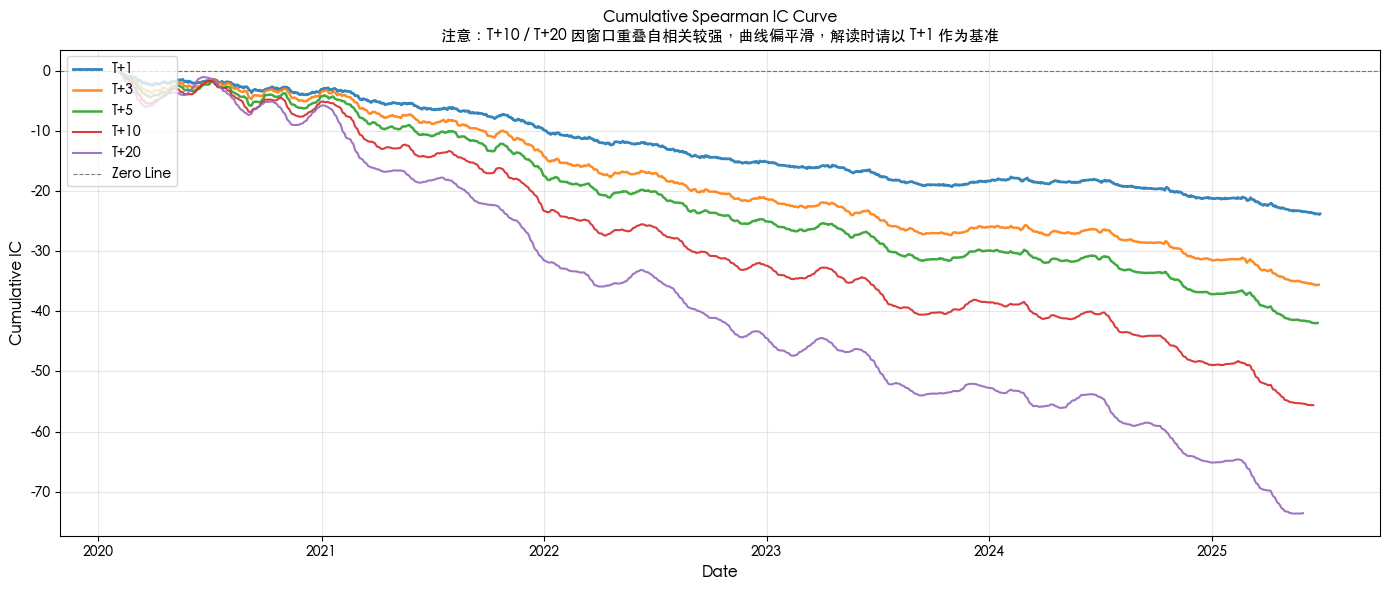

[4.1] 累计 IC 曲线已绘制并保存为 ic_cumulative_curve.png
  T+1  最终累计 IC = -23.768
  T+5  最终累计 IC = -41.926
  T+20 最终累计 IC = -73.593

  解读：
  - 曲线持续向右上方延伸 → 因子在整个样本期内稳定有效
  - 曲线出现平台或下降段 → 该时间段因子预测力消退，需关注市场风格切换
  - T+1 曲线的斜率是判断因子最可靠的参考（无窗口重叠偏差）


In [129]:
# ===========================================================
# 【IC 分析 - 模块四】累计 IC 曲线
# ===========================================================
print("=" * 60)
print("【IC 分析 - 模块四】累计 IC 曲线")
print("=" * 60)

# [累计 IC 曲线的含义]
# cumIC(t) = Σ_{s=1}^{t} IC(s)
# 该曲线不是投资组合的收益曲线，而是因子"预测能力在时间上的累积"。
# 斜率持续为正 → 因子长期稳定有效；斜率趋近 0 → 预测力消退；斜率负转 → 反向期。
# 用途：识别因子失效时间段（曲线平台期或下跌段），辅助因子调仓或下线决策。
#
# [为什么 T+10 / T+20 累计 IC 曲线更平滑]
# 相邻两日的 T+N 窗口有 N-1 天重叠，IC 序列高度自相关（T+20 约 95% 重叠），
# 高自相关会使 IC 序列波动变小，累计 IC 曲线看起来"更稳定、更漂亮"，
# 但这只是数学性质导致的视觉假象，不代表 T+20 比 T+1 因子更强。
# 解读时应以 T+1（无重叠，真实波动）为基准，T+20 仅供参考。

fig, ax = plt.subplots(figsize=(14, 6))

labels_map = {f'future_ret_T{N}': f'T+{N}' for N in CUMULATIVE_HORIZONS}
colors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
lwidths    = [2.0, 1.8, 1.8, 1.5, 1.5]    # T+1 线宽稍粗，突出最可信的基准线

for (col, label), color, lw in zip(labels_map.items(), colors, lwidths):
    
    ic = cum_ic_dict[col].dropna()
    print(f"{label}: ic.isna.sum: {ic.isna().sum()}")
    # 因为我们已经选取了非NaN的factor和ret的sub，然后去计算的ic，因此我们的ic是没有NaN的，只是不同的ret对应的ic的时间长度不同
    if len(ic) == 0:
        continue
    cum_ic = ic.sort_index().cumsum()       # 按日期排序后累加
    ax.plot(cum_ic.index, cum_ic.values, label=label, color=color,
            linewidth=lw, alpha=0.9)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5, label='Zero Line')
ax.set_title(
    'Cumulative Spearman IC Curve\n'
    '注意：T+10 / T+20 因窗口重叠自相关较强，曲线偏平滑，'
    '解读时请以 T+1 作为基准',
    fontsize=11
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Cumulative IC', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('ic_cumulative_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("[4.1] 累计 IC 曲线已绘制并保存为 ic_cumulative_curve.png")
print(f"  T+1  最终累计 IC = {cum_ic_dict['future_ret_T1'].dropna().sum():.3f}")
print(f"  T+5  最终累计 IC = {cum_ic_dict['future_ret_T5'].dropna().sum():.3f}")
print(f"  T+20 最终累计 IC = {cum_ic_dict['future_ret_T20'].dropna().sum():.3f}")
print(f"\n  解读：")
print(f"  - 曲线持续向右上方延伸 → 因子在整个样本期内稳定有效")
print(f"  - 曲线出现平台或下降段 → 该时间段因子预测力消退，需关注市场风格切换")
print(f"  - T+1 曲线的斜率是判断因子最可靠的参考（无窗口重叠偏差）")

T+20的波动比较大。考虑我们这个是累计IC的曲线，说明是在一定时间范围内，IC的震荡周期比较大，可能可以说成是共振。后续可以考虑自相关性去严格推导。

目前可以说明的就是，T+1的波动比较短，频率比较高，所以在积累曲线上较为稳定平滑
但是T+20的自相关强，波动的周期比较大，因子积累曲线上波动的周期就比T+1的要长。

【IC 分析 - 模块五】每日衰减 IC 图


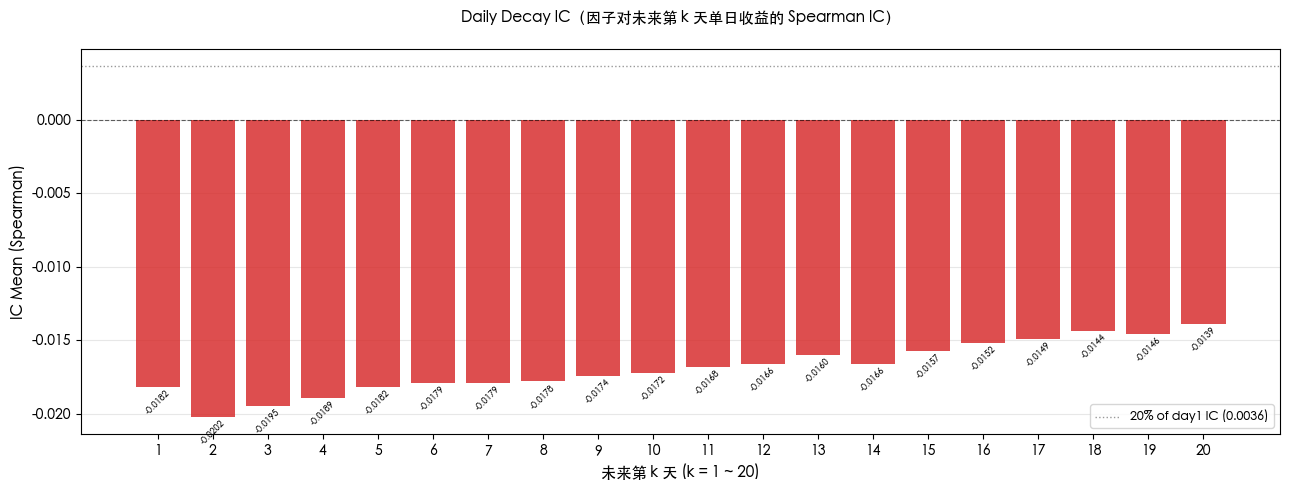

[5.1] 每日衰减 IC 图已绘制并保存为 ic_decay_daily.png

  day1  IC_mean = -0.0182（T+1 单日预测力，最直接的短期有效性指标）
  day5  IC_mean = -0.0182
  day10 IC_mean = -0.0172
  day20 IC_mean = -0.0139


In [130]:
# ===========================================================
# 【IC 分析 - 模块五】每日衰减 IC 图
# ===========================================================
print("=" * 60)
print("【IC 分析 - 模块五】每日衰减 IC 图")
print("=" * 60)

# 复用 decay_summary 已计算好的结果，提取 IC_mean
decay_ic_means = decay_summary['IC_mean'].values.astype(float)
days           = list(range(1, DECAY_DAYS + 1))

# 找到 IC_mean 首次不显著的天数（绝对值降至 T+1 的 20% 以下作为参考阈值）
ic_day1 = abs(decay_ic_means[0]) if not np.isnan(decay_ic_means[0]) else np.nan
threshold = ic_day1 * 0.2 if pd.notna(ic_day1) else None
decay_day = next(
    (k for k, v in enumerate(decay_ic_means, 1) if pd.notna(v) and abs(v) < threshold),
    None
) if threshold else None

fig, ax = plt.subplots(figsize=(13, 5))

bar_colors = ['#1f77b4' if (pd.notna(v) and v >= 0) else '#d62728'
              for v in decay_ic_means]
ax.bar(days, decay_ic_means, color=bar_colors, alpha=0.82, zorder=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

# 标注衰减阈值参考线
if threshold is not None:
    sign = np.sign(ic_day1) if pd.notna(ic_day1) else 1
    ax.axhline(sign * threshold, color='gray', linewidth=1.0,
               linestyle=':', alpha=0.8, label=f'20% of day1 IC ({sign*threshold:.4f})')

# 在柱顶标注 IC 值（字体稍小以免重叠）
for d, v in zip(days, decay_ic_means):
    if pd.notna(v):
        offset = 0.0001 if v >= 0 else -0.0001
        va     = 'bottom' if v >= 0 else 'top'
        ax.text(d, v + offset, f'{v:.4f}', ha='center', va=va, fontsize=6.5, rotation=45)

title_suffix = f'（预测力在 day{decay_day} 后衰减至 20% 以下）' if decay_day else ''
ax.set_title(
    f'Daily Decay IC（因子对未来第 k 天单日收益的 Spearman IC）\n{title_suffix}',
    fontsize=11
)
ax.set_xlabel('未来第 k 天 (k = 1 ~ 20)', fontsize=11)
ax.set_ylabel('IC Mean (Spearman)', fontsize=11)
ax.set_xticks(days)
if threshold:
    ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y', zorder=1)
fig.tight_layout()
plt.savefig('ic_decay_daily.png', dpi=150, bbox_inches='tight')
plt.show()

print("[5.1] 每日衰减 IC 图已绘制并保存为 ic_decay_daily.png")
print(f"\n  day1  IC_mean = {decay_ic_means[0]:.4f}（T+1 单日预测力，最直接的短期有效性指标）")
print(f"  day5  IC_mean = {decay_ic_means[4]:.4f}")
print(f"  day10 IC_mean = {decay_ic_means[9]:.4f}")
print(f"  day20 IC_mean = {decay_ic_means[19]:.4f}")
if decay_day:
    print(f"\n  参考：IC 在 day{decay_day} 左右衰减至 day1 的 20% 以下")
    if decay_day <= 3:
        print(f"  → 因子预测力衰减极快，属于短期/日内因子，建议持仓周期 ≤ {decay_day} 天")
    elif decay_day <= 10:
        print(f"  → 因子具备一定短中期预测力，持仓周期参考 {decay_day}~{decay_day*2} 天")
    else:
        print(f"  → 因子具备中期持续预测力，适合周频或以上换仓频率")

【IC 分析 - 模块六】分组收益分析

[6.1] 正在计算 T+{1,3,5,10,20} 的分组收益，请稍候...
  T+ 1 计算完成  G1=0.000432  G5=0.000373  G5-G1=-0.000059
  T+ 3 计算完成  G1=0.001792  G5=0.000960  G5-G1=-0.000832
  T+ 5 计算完成  G1=0.003200  G5=0.001510  G5-G1=-0.001689
  T+10 计算完成  G1=0.006518  G5=0.002500  G5-G1=-0.004019
  T+20 计算完成  G1=0.013060  G5=0.004008  G5-G1=-0.009052

──────────────────────────────────────────────────────────────────────
[6.2] 分组收益汇总表（各行为期限，各列为分组）
      G1=最低因子组，G5=最高因子组，G5-G1=多空组合收益
      若因子正向有效：期望 G1 < G2 < G3 < G4 < G5（单调递增）
      若 G5-G1 < 0：说明因子为反向因子（高值对应低未来收益）
──────────────────────────────────────────────────────────────────────
group       G1       G2       G3       G4       G5     G5-G1
T+1   0.000432 0.000738 0.000673 0.000496 0.000373 -0.000059
T+3   0.001792 0.002317 0.002003 0.001325 0.000960 -0.000832
T+5   0.003200 0.003798 0.003172 0.002120 0.001510 -0.001689
T+10  0.006518 0.006931 0.005732 0.003676 0.002500 -0.004019
T+20  0.013060 0.012843 0.010428 0.006997 0.004008 -0.009052

  [自动

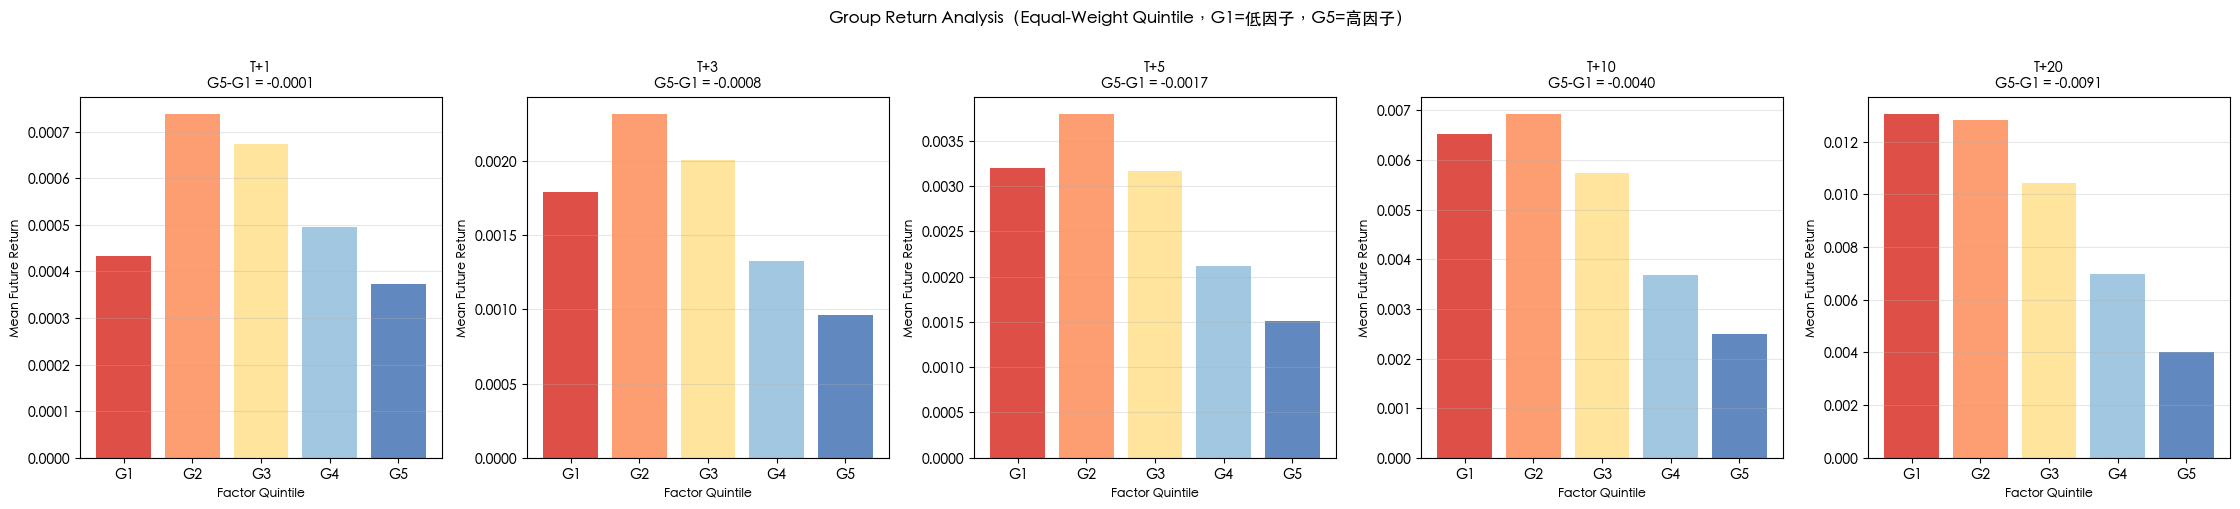


[6.3] 分组收益柱状图已绘制并保存为 ic_group_return.png
  图中 G1(红)→G5(蓝) 颜色渐变，若颜色从低到高对应收益单调递增，
  说明因子具备较强的截面区分能力；若颜色与收益高低不匹配，
  则因子单调性差，需结合 IC 汇总表综合判断因子质量

【IC 分析全部完成】输出文件：
  ic_cumulative_curve.png  - 累计 IC 曲线（T+1/T+3/T+5/T+10/T+20）
  ic_decay_daily.png       - 每日衰减 IC 柱状图（day1~day20）
  ic_group_return.png      - 分组收益柱状图（各期限 G1~G5）


In [147]:
# ===========================================================
# 【IC 分析 - 模块六】分组收益分析
# ===========================================================
print("=" * 60)
print("【IC 分析 - 模块六】分组收益分析")
print("=" * 60)

N_GROUPS = 5   # 分为 5 组：G1（最低因子）~ G5（最高因子）


# ── 6.1 calc_group_return_table ───────────────────────────────────────────────
def calc_group_return_table(df: pd.DataFrame,
                             return_col: str,
                             factor_col: str = 'factor',
                             n_groups: int = N_GROUPS) -> pd.Series:
    """
    在每日横截面上按 factor 将股票等分为 n_groups 组，
    计算每组的日均等权未来收益率，输出 G1~Gn 和 Gn-G1。

    [为什么先 dropna 再分组]
    pandas 默认不会把 NaN 分入任何分组，但若不显式过滤，
    NaN 的 factor 行可能参与 groupby 计算（某些版本行为不同）。
    显式过滤确保分组基准明确，量化中"宁可损失样本量也不引入不确定性"。

    [为什么按日分组而不是全样本分组]
    因子值的分布随市场环境变化（均值漂移、波动率变化），
    若全样本 qcut，某一时间段内的所有股票可能都落入同一组，
    分组失去横截面比较的意义。日内分组保证每天等分，
    是量化行业横截面分组的标准做法。

    [为什么用 rank(pct=True) + ceil 而不是 groupby.apply(qcut)]
    qcut 在 transform 中每日调用一次（约 1300 次 Python 函数），
    而 rank(pct=True) 是全量向量化操作，速度快约一个数量级。
    ceil(rank * n_groups).clip(1, n_groups) 与等分位数分组等价：
      最低 1/N 分位 → ceil(1/N * 5) = 1 → G1
      最高 N/N 分位 → ceil(1.0 * 5) = 5 → G5
    """
    mask = df[factor_col].notna() & df[return_col].notna()
    if 'valid_obs' in df.columns:
        mask = mask & df['valid_obs'].fillna(False)

    sub = df.loc[mask, ['date', factor_col, return_col]].copy()
    if len(sub) == 0:
        print(f"  [警告] {return_col} 无有效样本，跳过")
        return None

    # 每日横截面内 factor 的百分位排名（0~1 之间），全量向量化
    pct_rank      = sub.groupby('date')[factor_col].rank(method='average', pct=True)
    # 使用average，使得收益率相等的股票的排名是一致的，不额外引入筛选
    # 再转化为0-1的排名，最后根据区间5等分，分的是区间，并不是数量五等分
    # 如果其factor为NaN，则在rank里面输出的也是NaN，并不会输出百分位排名

    # 转换为 1~n_groups 的整数分组标签
    sub['group']  = np.ceil(pct_rank * n_groups).clip(1, n_groups).astype(int)
    # ceil就是向上取整，得到的是左开右闭区间，比如(0.2,0.4] 变成(1,2],看起来就是G2
    # ceil向上取整得到的是浮点数
    # pct只在0-1，那么乘上rank也小于等于n_group，不过为了防止有溢出，选择clip(min,max)封锁，大于max的数会变为max
    # 然后在转化为int存储，去掉后面的小数部分

    sub['group']  = 'G' + sub['group'].astype(str)

    # 每日每组的等权平均收益，再在时间轴上取均值
    # 两步取均值等价于"等权日均组合收益的时间序列均值"，
    # 是量化行业分组收益的标准计算方式（避免某一天样本量特别大导致偏权重）
    group_daily  = sub.groupby(['date', 'group'])[return_col].mean().unstack('group')
    group_mean   = group_daily.mean()   # 时间序列均值
    # sub.groupby(['date', 'group'])[return_col].mean()就是按照date和group分类后，取ret列，求平均。
    # unstack('group')就是把group从行标签变成列标签
    # 此时得到的group_daily就是，以date为行，group为列，内容是当日当组的收益率的均值
    # group_mean就是对date求平均，按理说是行被压缩，得到一行五列的数据。
    # 但是也就是一维数据，是Series存储的，可以理解成是一列五行。每行就是G1，G2等等

    # 按 G1~G5 排序，补全缺失分组为 NaN
    all_groups  = [f'G{i}' for i in range(1, n_groups + 1)]
    group_mean  = group_mean.reindex(all_groups)
    # 对于group_mean，我们不清楚G1G2是否顺序正确，也不知道是否有5组数据，因为我们只是分组，没有按顺序
    # 于是，我们让group_mean，按照我们给的all_groups作为index，重新排序

    # 多空收益 Gn - G1（做多最高组、做空最低组）
    if pd.notna(group_mean.get('G5')) and pd.notna(group_mean.get('G1')):
        group_mean[f'G{n_groups}-G1'] = group_mean[f'G{n_groups}'] - group_mean['G1']

    return group_mean


# ── 6.2 批量计算分组收益 ─────────────────────────────────────────────────────
print(f"\n[6.1] 正在计算 T+{{1,3,5,10,20}} 的分组收益，请稍候...")
group_result = {}

for N in CUMULATIVE_HORIZONS:
    col    = f'future_ret_T{N}'
    result = calc_group_return_table(df, return_col=col)
    if result is not None:
        group_result[f'T+{N}'] = result
        print(f"  T+{N:2d} 计算完成  "
              f"G1={result.get('G1', np.nan):.6f}  "
              f"G5={result.get('G5', np.nan):.6f}  "
              f"G5-G1={result.get('G5-G1', np.nan):.6f}")

group_ret_table = pd.DataFrame(group_result).T

print("\n" + "─" * 70)
print("[6.2] 分组收益汇总表（各行为期限，各列为分组）")
print("      G1=最低因子组，G5=最高因子组，G5-G1=多空组合收益")
print("      若因子正向有效：期望 G1 < G2 < G3 < G4 < G5（单调递增）")
print("      若 G5-G1 < 0：说明因子为反向因子（高值对应低未来收益）")
print("─" * 70)
print(group_ret_table.to_string(float_format=lambda x: f'{x:.6f}'))

# 自动判断因子方向
t1_row = group_ret_table.loc['T+1'] if 'T+1' in group_ret_table.index else None
if t1_row is not None and pd.notna(t1_row.get('G5-G1')):
    ls = t1_row['G5-G1']
    if ls > 0:
        print(f"\n  [自动判断] T+1 G5-G1 = {ls:.6f} > 0 → 因子为正向因子（高值对应高未来收益）")
    else:
        print(f"\n  [自动判断] T+1 G5-G1 = {ls:.6f} < 0 → 因子为反向因子，IC 分析中因子方向需取反解读")


# ── 6.3 分组收益柱状图 ───────────────────────────────────────────────────────
n_horizons = len(group_result)
fig, axes  = plt.subplots(1, n_horizons,
                           figsize=(4.5 * n_horizons, 5),
                           sharey=False)
if n_horizons == 1:
    axes = [axes]

# G1(红)→G5(蓝) 渐变色，直观反映因子分位
GROUP_COLORS = ['#d73027', '#fc8d59', '#fee08b', '#91bfdb', '#4575b4']

for ax, (horizon, row) in zip(axes, group_result.items()):
    groups = [f'G{i}' for i in range(1, N_GROUPS + 1)]
    values = [row.get(g, np.nan) for g in groups]
    valid  = [(g, v) for g, v in zip(groups, values) if pd.notna(v)]

    if valid:
        gs, vs = zip(*valid)
        colors_used = [GROUP_COLORS[int(g[1:]) - 1] for g in gs]
        ax.bar(gs, vs, color=colors_used, alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    ls_val = row.get(f'G{N_GROUPS}-G1', np.nan)
    ls_str = f'G5-G1 = {ls_val:.4f}' if pd.notna(ls_val) else 'G5-G1 = N/A'
    ax.set_title(f'{horizon}\n{ls_str}', fontsize=10)
    ax.set_xlabel('Factor Quintile', fontsize=9)
    ax.set_ylabel('Mean Future Return', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Group Return Analysis（Equal-Weight Quintile，G1=低因子，G5=高因子）',
             fontsize=12, y=1.01)
fig.tight_layout()
plt.savefig('ic_group_return.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[6.3] 分组收益柱状图已绘制并保存为 ic_group_return.png")
print(f"  图中 G1(红)→G5(蓝) 颜色渐变，若颜色从低到高对应收益单调递增，")
print(f"  说明因子具备较强的截面区分能力；若颜色与收益高低不匹配，")
print(f"  则因子单调性差，需结合 IC 汇总表综合判断因子质量")
print(f"\n【IC 分析全部完成】输出文件：")
print(f"  ic_cumulative_curve.png  - 累计 IC 曲线（T+1/T+3/T+5/T+10/T+20）")
print(f"  ic_decay_daily.png       - 每日衰减 IC 柱状图（day1~day20）")
print(f"  ic_group_return.png      - 分组收益柱状图（各期限 G1~G5）")

# 总结
G5-G1 = -91 bps（T+20 累计）看起来不小，但折算成日均只有 -0.5 bps，几乎被交易成本吃光

G1 并非最高收益组（G2 更高），说明因子在底部非单调，无法简单用"做多 G1 做空 G5"构造干净的多空组合
最有价值的观察是 G2~G5 的单调性是干净的，这说明因子的主要预测力来自"识别哪些股票未来会跑输"（G5 最差），而非精确区分中高分位

这个因子更适合作为排除信号（回避 G5 高分位股票），而非构建多空对冲策略的双边信号。